# Prediccion de Enfermedad Renal Cronica (ERC) mediante Machine Learning
## Clasificacion Binaria Supervisada | Dataset NHANES 2021-2023

**Pregunta:** Es posible predecir la presencia de ERC a partir de variables clinicas, demograficas y de laboratorio mediante modelos de aprendizaje automatico supervisado con clasificacion binaria?

**Target:** `ckd_present` (0/1) | **Metrica:** AUC-ROC | **Dataset:** 11,933 registros

---
## FASE 0: Librerias

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
pd.set_option("display.max_columns", 35)
print("Librerias OK")

Librerias OK


---
## FASE 1: Carga y exploracion inicial

In [2]:
df = pd.read_csv("../data/CKD_NHANES_2021_2023.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (11933, 29)


,participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,serum_creatinine,blood_urea_nitrogen,albumin_serum,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_stage,ckd_present
0,130378.0,43.0,Male,Non-Hispanic Asian,5.0,5.00,27.0,86.9,179.5,135.0,98.0,0.80,11.0,4.3,3.7,24.0,9.6,5.1,136.0,23.12,17.00,2.0,NaN,NaN,1.0,3.0,112.61,No CKD,0
1,130379.0,66.0,Male,Non-Hispanic White,5.0,5.00,33.5,101.8,174.2,121.0,84.0,0.79,24.0,3.9,3.2,25.0,9.4,8.5,64.0,4.25,6.64,2.0,NaN,NaN,1.0,3.0,97.98,No CKD,0
2,130380.0,44.0,Female,Other Hispanic,3.0,1.41,29.7,69.4,152.9,111.0,79.0,0.64,10.0,3.7,3.8,25.0,9.4,4.4,157.0,12.43,7.92,1.0,2.0,1.0,2.0,NaN,111.69,No CKD,0
3,130381.0,5.0,Female,Other/Multiracial,NaN,1.53,23.8,34.3,120.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,208.0,16.12,7.75,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1
4,130382.0,2.0,Male,Non-Hispanic White,NaN,3.60,NaN,13.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11933 entries, 0 to 11932
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   participant_id            11933 non-null  float64
 1   age                       11933 non-null  float64
 2   gender                    11933 non-null  str    
 3   ethnicity                 11933 non-null  str    
 4   education_level           7794 non-null   float64
 5   poverty_income_ratio      9892 non-null   float64
 6   bmi                       8471 non-null   float64
 7   weight_kg                 8754 non-null   float64
 8   height_cm                 8499 non-null   float64
 9   bp_systolic               7517 non-null   float64
 10  bp_diastolic              7517 non-null   float64
 11  serum_creatinine          6326 non-null   float64
 12  blood_urea_nitrogen       6326 non-null   float64
 13  albumin_serum             6366 non-null   float64
 14  phosphorus       

In [4]:
df.describe().round(2)

,participant_id,age,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,serum_creatinine,blood_urea_nitrogen,albumin_serum,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_present
count,11933.0,11933.00,7794.00,9892.00,8471.00,8754.00,8499.00,7517.00,7517.00,6326.00,6326.00,6366.00,6322.00,6325.00,6362.00,6329.00,8154.00,8153.00,8153.00,11740.00,1081.00,2281.00,8135.00,3243.00,6326.00,11933.00
mean,136344.0,38.32,3.80,2.71,27.25,70.55,159.66,119.29,72.75,0.87,14.66,4.10,3.61,24.45,9.43,5.13,133.26,35.57,33.36,1.93,1.68,1.63,1.61,2.34,96.60,0.70
std,3444.9,25.60,1.15,1.67,8.14,30.39,19.86,18.56,11.90,0.39,5.75,0.36,0.57,2.41,0.38,1.41,90.68,175.58,251.09,0.36,0.47,0.64,0.56,0.90,24.63,0.46
min,130378.0,0.00,1.00,0.00,11.10,2.70,79.10,61.00,33.00,0.33,4.00,2.20,1.60,15.00,7.50,1.10,4.00,0.21,0.08,1.00,1.00,1.00,1.00,1.00,3.51,0.00
25%,133361.0,13.00,3.00,1.18,21.60,54.20,154.40,106.00,64.00,0.70,11.00,3.90,3.20,23.00,9.20,4.10,65.00,5.77,5.42,2.00,1.00,1.00,1.00,1.00,80.50,0.00
50%,136344.0,37.00,4.00,2.50,26.40,71.70,163.60,117.00,72.00,0.83,14.00,4.10,3.60,24.00,9.40,5.00,117.00,9.62,8.27,2.00,2.00,2.00,2.00,3.00,97.03,1.00
75%,139327.0,62.00,5.00,4.50,31.70,89.10,172.10,130.00,80.00,0.98,17.00,4.30,3.90,26.00,9.70,6.00,181.00,17.83,15.33,2.00,2.00,2.00,2.00,3.00,112.66,1.00
max,142310.0,80.00,9.00,5.00,74.80,248.20,200.70,232.00,142.00,15.17,74.00,5.50,7.00,37.00,11.70,13.20,873.00,7942.47,14708.28,9.00,2.00,9.00,9.00,3.00,178.43,1.00


In [5]:
# Nulos
nulos = df.isnull().sum().sort_values(ascending=False)
nulos_pct = (nulos / len(df) * 100).round(1)
pd.DataFrame({"Nulos": nulos, "%": nulos_pct})[nulos > 0]

,Nulos,%
insulin_use,10852,90.9
diabetes_pills,9652,80.9
current_smoker,8690,72.8
phosphorus,5611,47.0
bicarbonate,5608,47.0
blood_urea_nitrogen,5607,47.0
serum_creatinine,5607,47.0
egfr,5607,47.0
uric_acid,5604,47.0
calcium,5571,46.7


ckd_present
1    8341
0    3592
Name: count, dtype: int64

CKD: 69.9% | No CKD: 30.1%


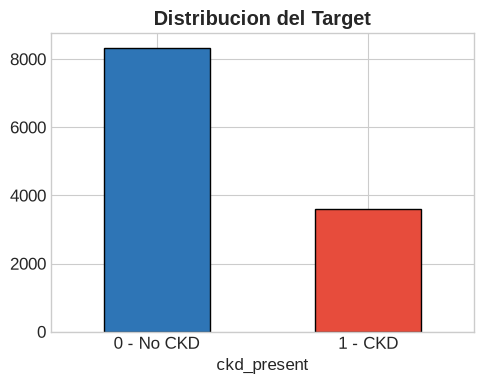

In [6]:
# Target
print(df["ckd_present"].value_counts())
print(
    f"\nCKD: {df['ckd_present'].mean() * 100:.1f}% | No CKD: {(1 - df['ckd_present'].mean()) * 100:.1f}%"
)

fig, ax = plt.subplots(figsize=(5, 4))
df["ckd_present"].value_counts().plot(
    kind="bar", color=["#2E75B6", "#E74C3C"], edgecolor="black", ax=ax
)
ax.set_title("Distribucion del Target", fontweight="bold")
ax.set_xticklabels(["0 - No CKD", "1 - CKD"], rotation=0)
plt.tight_layout()
plt.show()

---
## FASE 2: Eliminacion de variables (fuga + redundancia)

| Variable | Razon | Tipo |
|---|---|---|
| `egfr` | Define el target (eGFR<60 = CKD) | Fuga directa |
| `ckd_stage` | Derivada de eGFR + ACR | Fuga directa |
| `serum_creatinine` | Insumo de CKD-EPI: eGFR=f(creatinina,edad,sexo) | Fuga proxy |
| `participant_id` | ID sin valor predictivo | N/A |
| `weight_kg`, `height_cm` | Redundantes con BMI | Redundancia |
| `insulin_use` | 91% nulos | Nulos excesivos |
| `diabetes_pills` | 81% nulos | Nulos excesivos |
| `current_smoker` | 73% nulos | Nulos excesivos |
| `urine_albumin` | Redundante con ACR (ACR = ualb/ucr) | Redundancia |

In [7]:
vars_eliminar = [
    "participant_id",
    "egfr",
    "ckd_stage",
    "serum_creatinine",
    "weight_kg",
    "height_cm",
    "insulin_use",
    "diabetes_pills",
    "current_smoker",
    "urine_albumin",  # redundante con ACR
]
print(f"Antes: {df.shape[1]} columnas")
df_clean = df.drop(columns=vars_eliminar)
print(f"Despues: {df_clean.shape[1]} columnas")
print(f"Conservadas: {list(df_clean.columns)}")
# Filtrar adultos (>=20) para alinear con GBD (ERC pediatrica es otra entidad)
print(f"Registros: {len(df_clean)}")
df_clean = df_clean[df_clean["age"] >= 20].reset_index(drop=True)
print(f"Adultos >=20: {len(df_clean)} ({len(df_clean) / len(df) * 100:.1f}%)")

Antes: 29 columnas
Despues: 19 columnas
Conservadas: ['age', 'gender', 'ethnicity', 'education_level', 'poverty_income_ratio', 'bmi', 'bp_systolic', 'bp_diastolic', 'blood_urea_nitrogen', 'albumin_serum', 'phosphorus', 'bicarbonate', 'calcium', 'uric_acid', 'urine_creatinine', 'albumin_creatinine_ratio', 'diabetes_diagnosed', 'ever_smoked', 'ckd_present']
Registros: 11933
Adultos >=20: 7809 (65.4%)


---
## FASE 3: Tratamiento de datos

### 3.1 Recodificacion

In [8]:
# diabetes_diagnosed: 1=si, 2=no, 3=borderline, 9=no sabe
print("Original:", df_clean["diabetes_diagnosed"].value_counts().to_dict())
df_clean["diabetes_diagnosed"] = df_clean["diabetes_diagnosed"].replace(
    {1: 1, 2: 0, 3: 0, 9: np.nan}
)
print(
    "Recodificado:", df_clean["diabetes_diagnosed"].value_counts(dropna=False).to_dict()
)

Original: {2.0: 6466, 1.0: 1070, 3.0: 270, 9.0: 1}
Recodificado: {0.0: 6736, 1.0: 1070, nan: 3}


### 3.2 Filtrado de registros sin laboratorios

In [9]:
# Los ~47% de nulos en labs son los mismos pacientes sin examenes de sangre
# Guardar copia ANTES del filtrado para comparar despues
df_antes_filtro = df_clean.copy()

# Filtrar: conservar registros que tengan labs
df_labs = df_clean.dropna(subset=["blood_urea_nitrogen"])
print(
    f"Registros con labs: {len(df_labs)} de {len(df_clean)} ({len(df_labs) / len(df_clean) * 100:.1f}%)"
)
print(f"Target: {df_labs['ckd_present'].value_counts().to_dict()}")
print(f"CKD: {df_labs['ckd_present'].mean() * 100:.1f}%")

Registros con labs: 5444 de 7809 (69.7%)
Target: {0: 2824, 1: 2620}
CKD: 48.1%


In [10]:
# Nulos restantes
nulos_post = df_labs.isnull().sum().sort_values(ascending=False)
nulos_pct_post = (nulos_post / len(df_labs) * 100).round(1)
print("Nulos restantes:")
print(pd.DataFrame({"Nulos": nulos_post, "%": nulos_pct_post})[nulos_post > 0])

Nulos restantes:
                          Nulos     %
poverty_income_ratio        700  12.9
bp_systolic                 167   3.1
bp_diastolic                167   3.1
albumin_creatinine_ratio    100   1.8
urine_creatinine            100   1.8
bmi                          72   1.3
phosphorus                   19   0.3
bicarbonate                   1   0.0
calcium                       1   0.0


### 3.3 Transformacion logaritmica de variables sesgadas

In [11]:
# Guardar valores ANTES de transformar para el boxplot comparativo
acr_antes = df_labs["albumin_creatinine_ratio"].copy()

log_vars = ["albumin_creatinine_ratio"]
for var in log_vars:
    print(f"{var}:")
    print(f"  Skewness ANTES: {df_labs[var].skew():.2f}")
    df_labs[var] = np.log1p(df_labs[var])
    print(f"  Skewness DESPUES: {df_labs[var].skew():.2f}\n")

albumin_creatinine_ratio:
  Skewness ANTES: 30.67
  Skewness DESPUES: 1.52



### 3.4 Comparacion ANTES vs DESPUES del tratamiento de datos

Boxplots lado a lado para ver el efecto de la transformacion logaritmica y la limpieza.

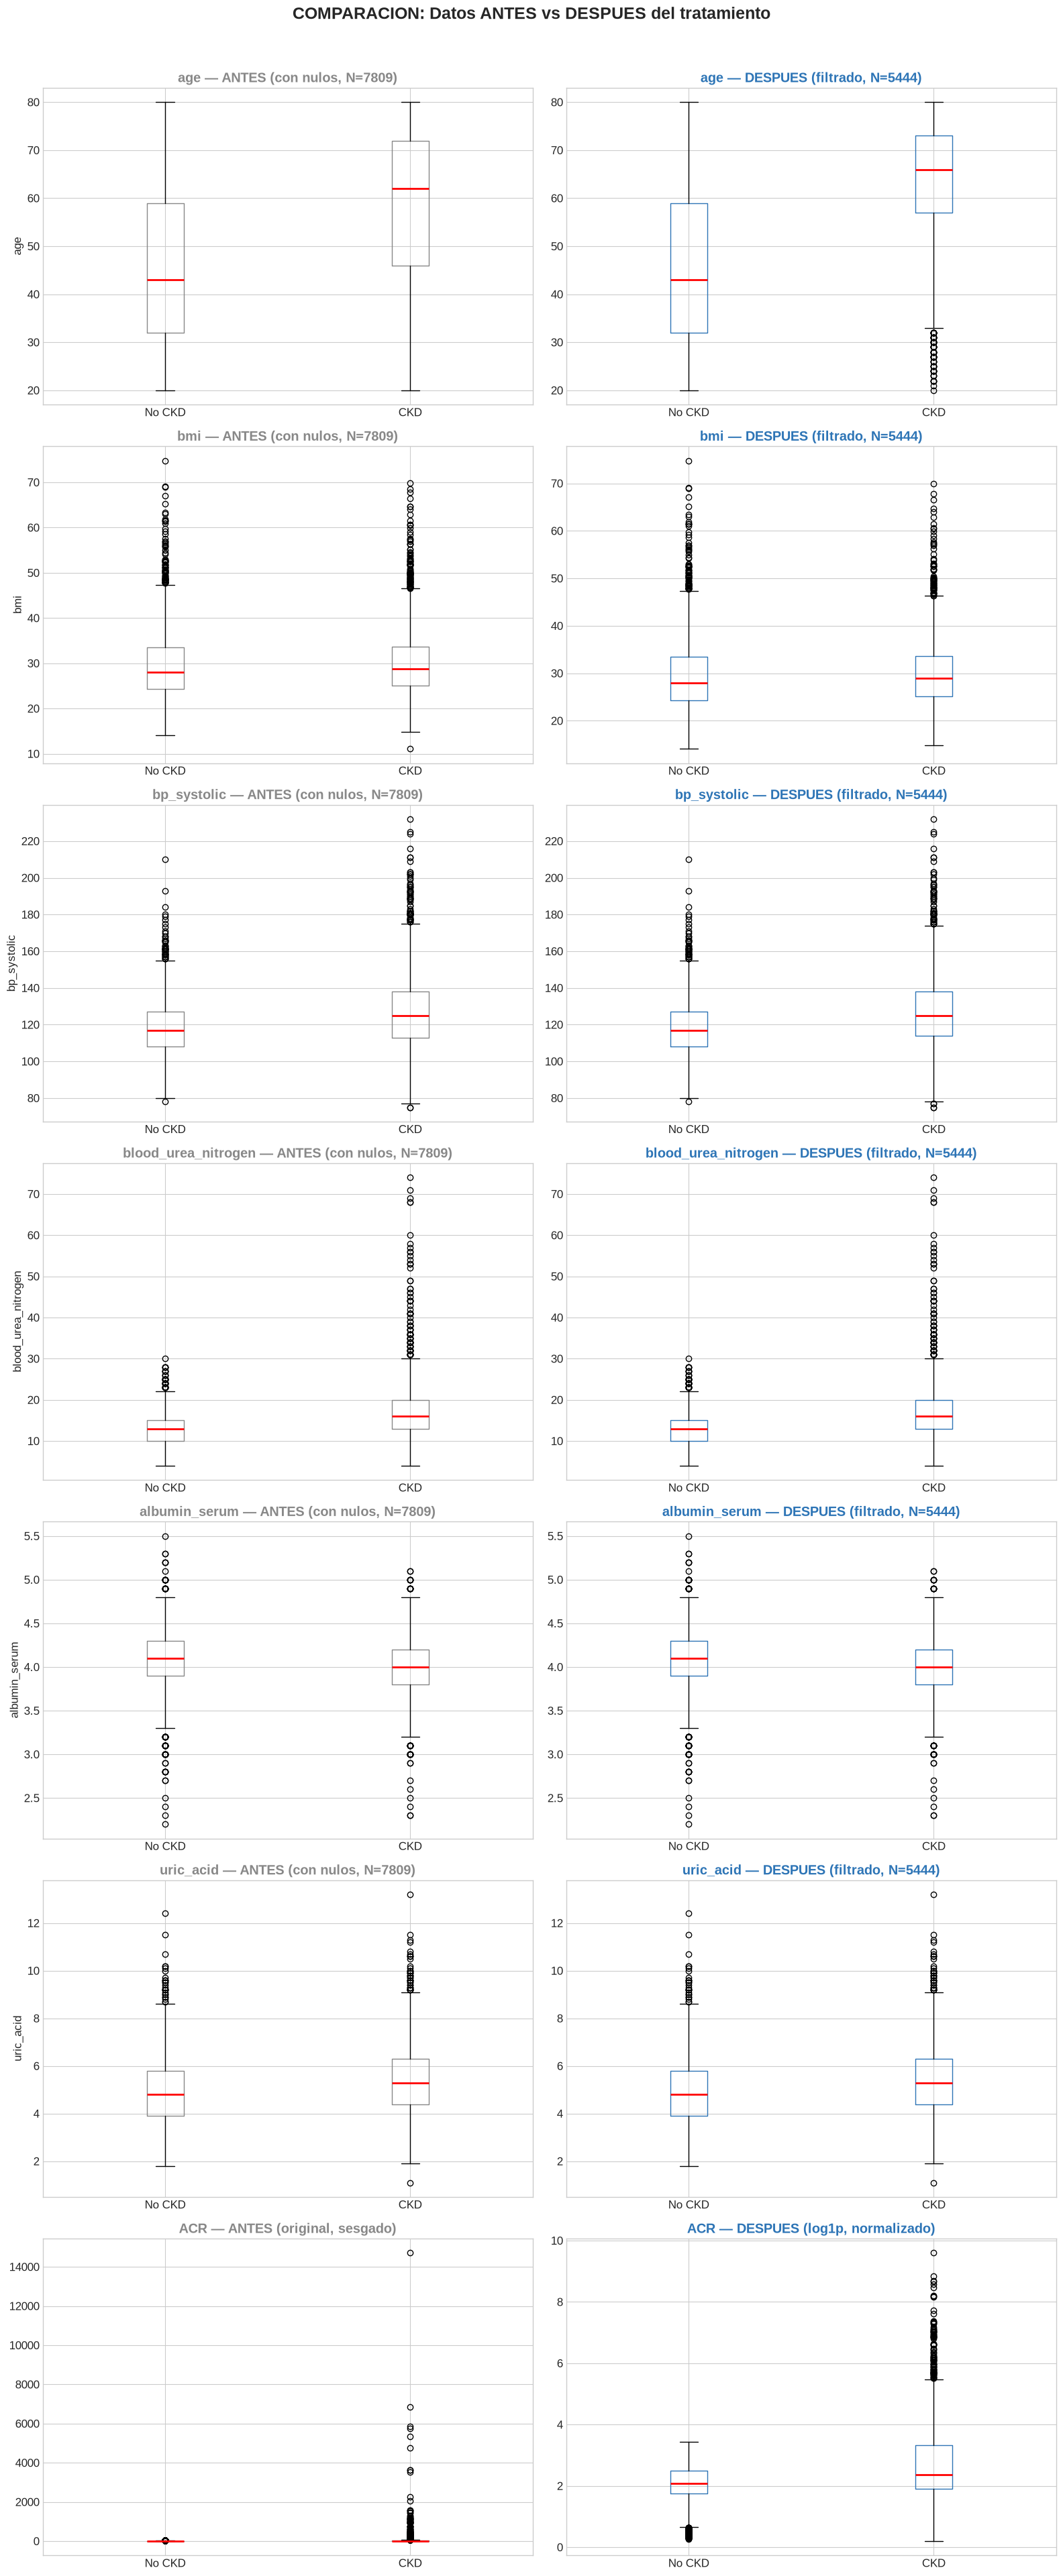

In [12]:
# ====================================================================
# BOXPLOTS COMPARATIVOS: ANTES vs DESPUES del tratamiento
# ====================================================================
compare_vars = [
    "age",
    "bmi",
    "bp_systolic",
    "blood_urea_nitrogen",
    "albumin_serum",
    "uric_acid",
]

fig, axes = plt.subplots(7, 2, figsize=(16, 38))

# --- Variables normales: antes (df_antes_filtro) vs despues (df_labs) ---
for i, var in enumerate(compare_vars):
    row = i
    # ANTES
    data_antes_0 = df_antes_filtro.loc[
        df_antes_filtro["ckd_present"] == 0, var
    ].dropna()
    data_antes_1 = df_antes_filtro.loc[
        df_antes_filtro["ckd_present"] == 1, var
    ].dropna()
    axes[row][0].boxplot(
        [data_antes_0, data_antes_1],
        tick_labels=["No CKD", "CKD"],
        boxprops={"color": "#888"},
        medianprops={"color": "red", "linewidth": 2},
    )
    axes[row][0].set_title(
        f"{var} — ANTES (con nulos, N={len(df_antes_filtro)})",
        fontweight="bold",
        color="#888",
    )
    axes[row][0].set_ylabel(var)

    # DESPUES
    data_desp_0 = df_labs.loc[df_labs["ckd_present"] == 0, var].dropna()
    data_desp_1 = df_labs.loc[df_labs["ckd_present"] == 1, var].dropna()
    axes[row][1].boxplot(
        [data_desp_0, data_desp_1],
        tick_labels=["No CKD", "CKD"],
        boxprops={"color": "#2E75B6"},
        medianprops={"color": "red", "linewidth": 2},
    )
    axes[row][1].set_title(
        f"{var} — DESPUES (filtrado, N={len(df_labs)})",
        fontweight="bold",
        color="#2E75B6",
    )

    if i >= 5:
        break

# --- ACR: antes (original) vs despues (log) ---
# ACR ANTES
d0 = acr_antes[df_labs["ckd_present"] == 0].dropna()
d1 = acr_antes[df_labs["ckd_present"] == 1].dropna()
axes[6][0].boxplot(
    [d0, d1],
    tick_labels=["No CKD", "CKD"],
    boxprops={"color": "#888"},
    medianprops={"color": "red", "linewidth": 2},
)
axes[6][0].set_title("ACR — ANTES (original, sesgado)", fontweight="bold", color="#888")

# ACR DESPUES (log)
d0l = df_labs.loc[df_labs["ckd_present"] == 0, "albumin_creatinine_ratio"].dropna()
d1l = df_labs.loc[df_labs["ckd_present"] == 1, "albumin_creatinine_ratio"].dropna()
axes[6][1].boxplot(
    [d0l, d1l],
    tick_labels=["No CKD", "CKD"],
    boxprops={"color": "#2E75B6"},
    medianprops={"color": "red", "linewidth": 2},
)
axes[6][1].set_title(
    "ACR — DESPUES (log1p, normalizado)", fontweight="bold", color="#2E75B6"
)

plt.suptitle(
    "COMPARACION: Datos ANTES vs DESPUES del tratamiento",
    fontsize=18,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

---
## FASE 4: EDA sobre datos tratados

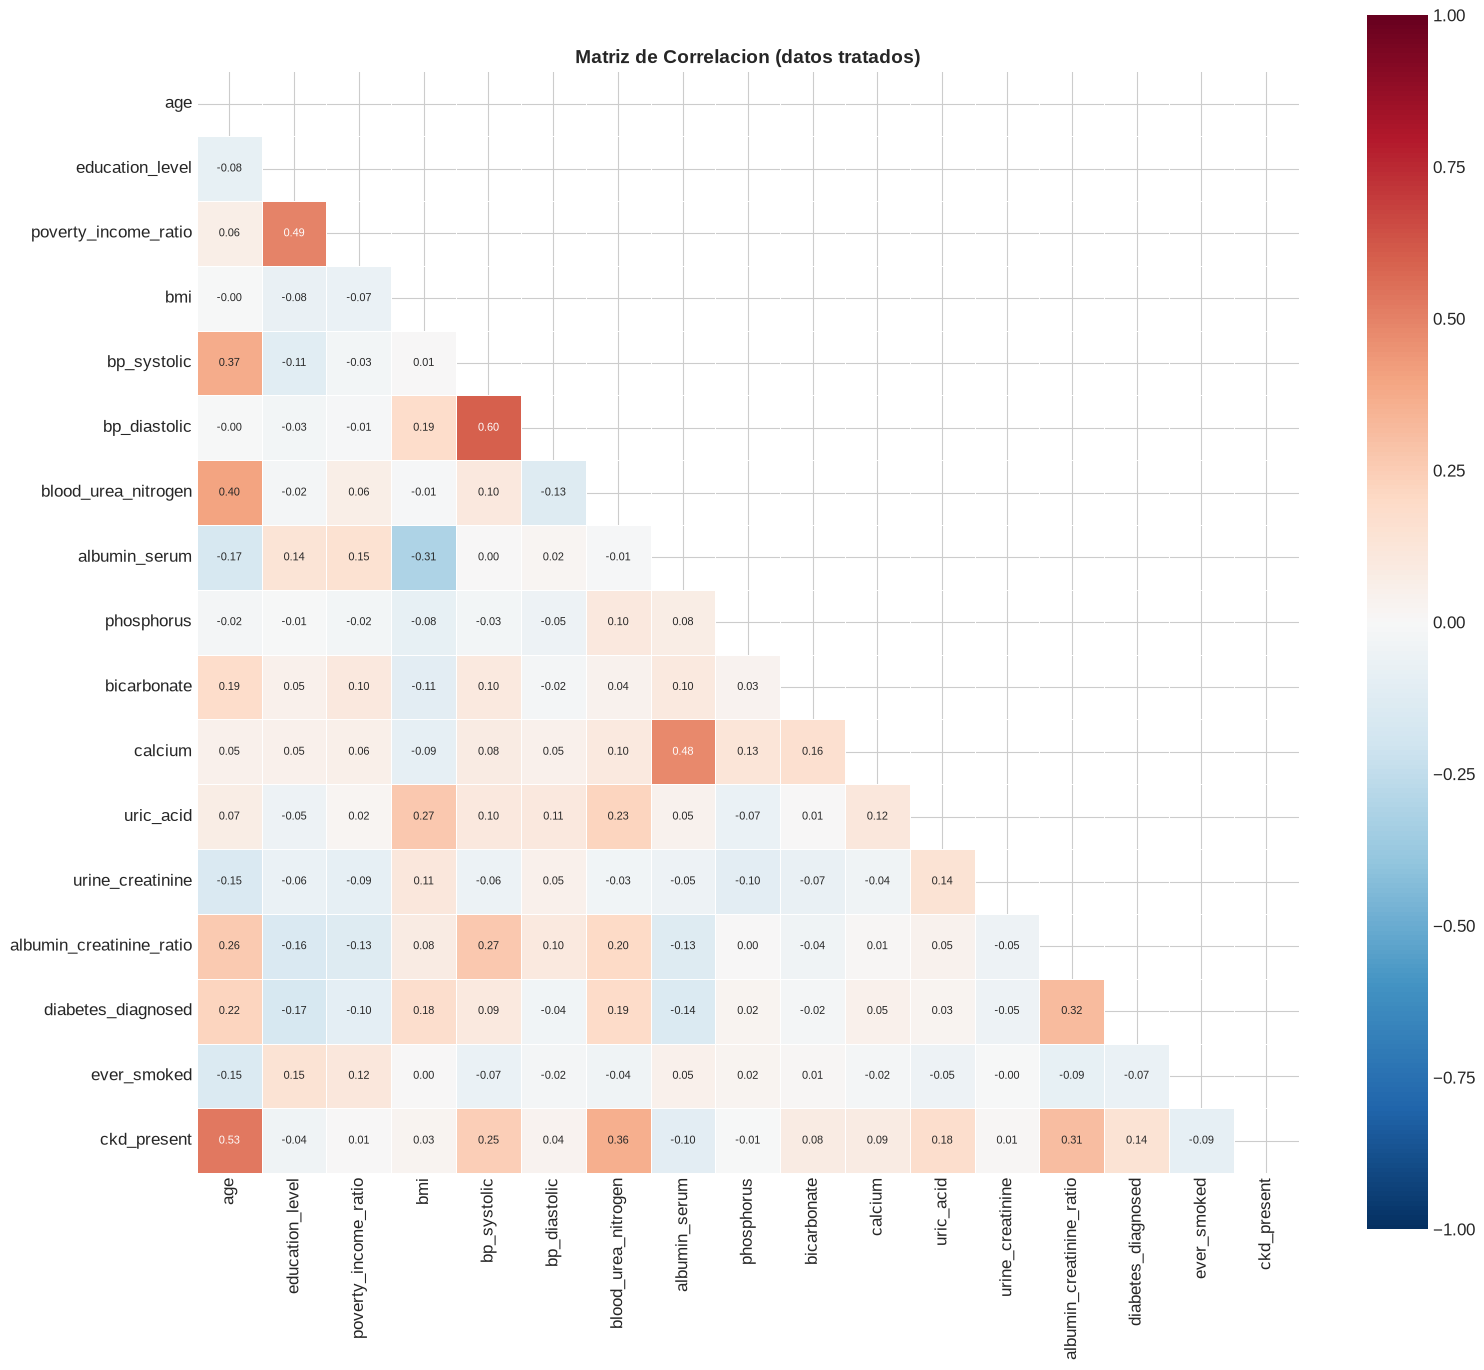

In [13]:
# Matriz de correlacion
num_data = df_labs.select_dtypes(include=[np.number])
corr = num_data.corr()

plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    annot_kws={"size": 8},
)
plt.title("Matriz de Correlacion (datos tratados)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

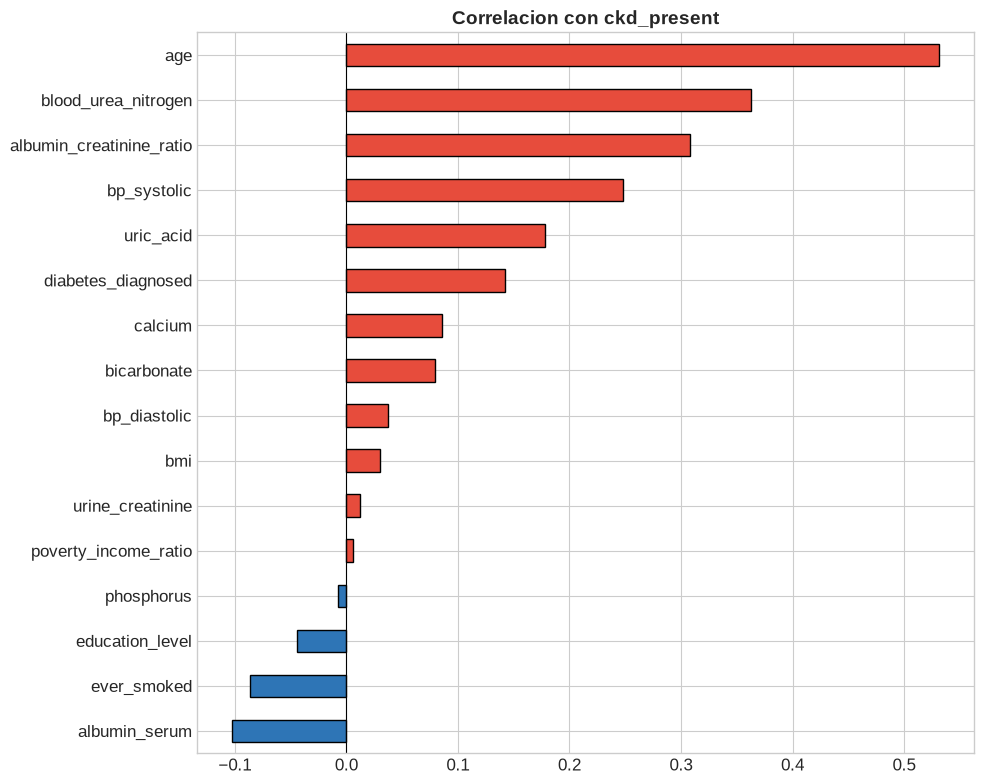

In [14]:
# Correlacion con target
corr_target = num_data.corr()["ckd_present"].drop("ckd_present").sort_values()
plt.figure(figsize=(10, 8))
colors = ["#E74C3C" if x > 0 else "#2E75B6" for x in corr_target.values]
corr_target.plot(kind="barh", color=colors, edgecolor="black")
plt.title("Correlacion con ckd_present", fontsize=14, fontweight="bold")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

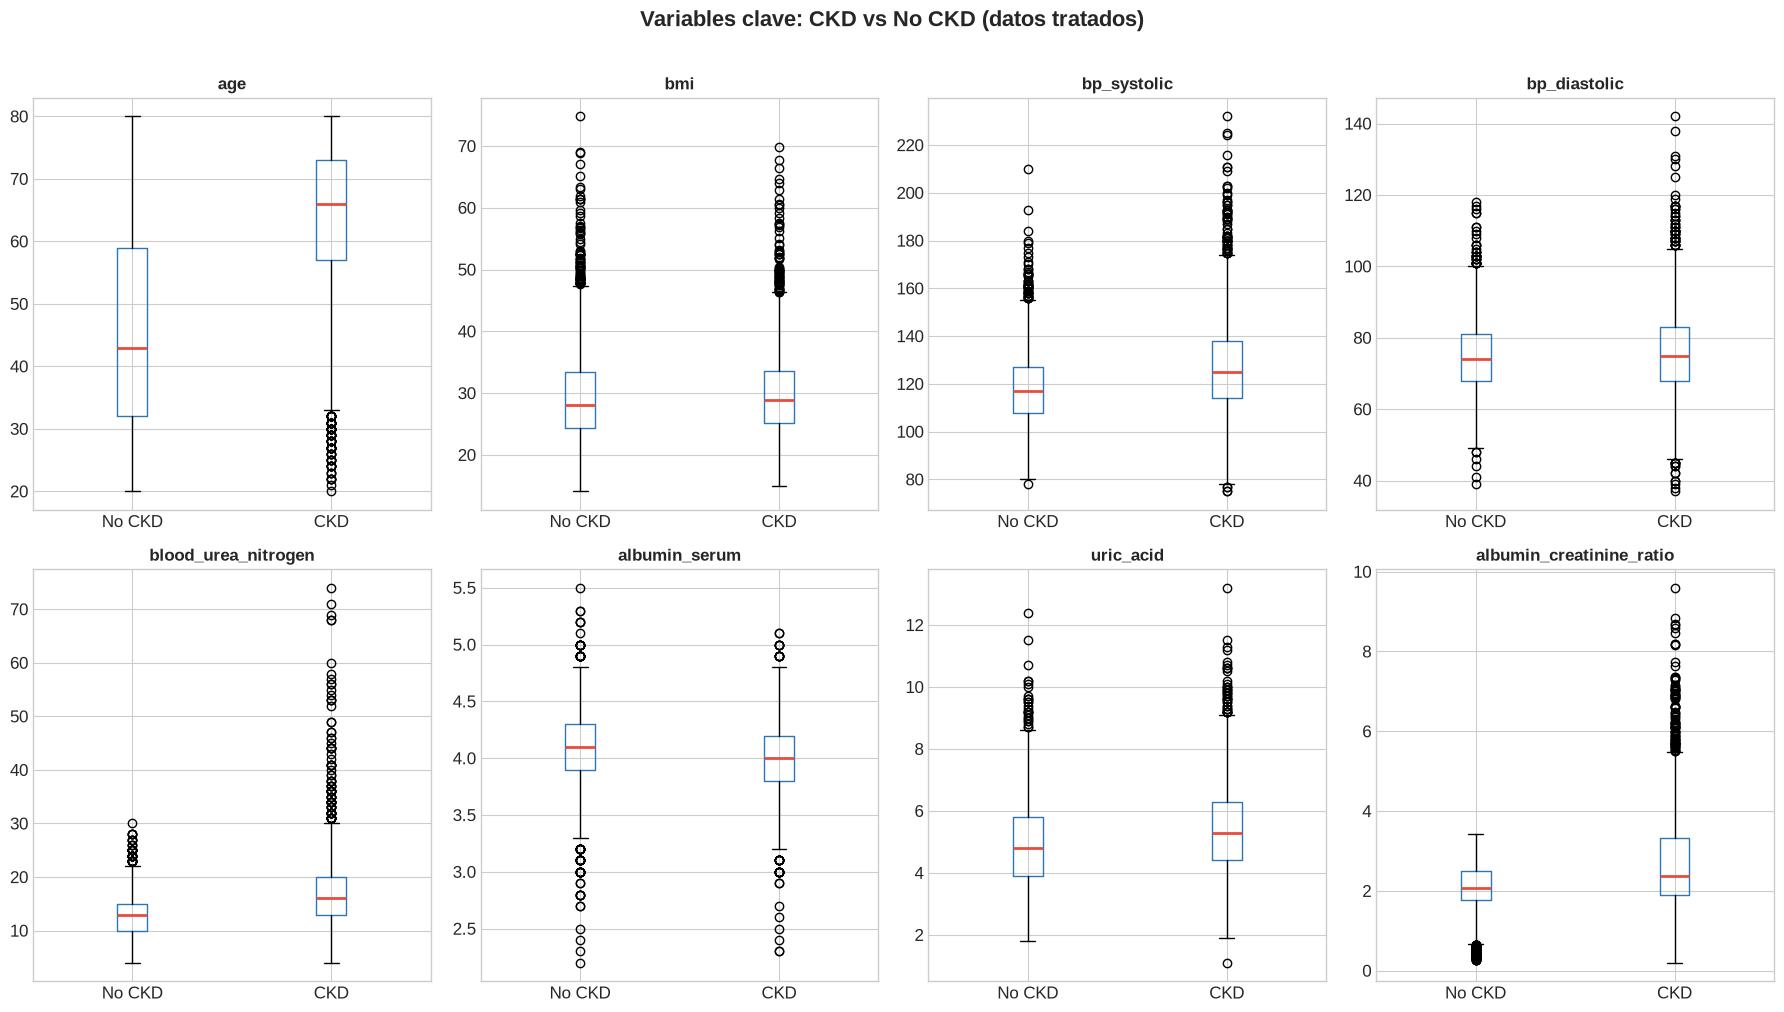

In [15]:
# Boxplots limpios finales
key_vars = [
    "age",
    "bmi",
    "bp_systolic",
    "bp_diastolic",
    "blood_urea_nitrogen",
    "albumin_serum",
    "uric_acid",
    "albumin_creatinine_ratio",
]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(key_vars):
    ax = axes[i]
    d0 = df_labs.loc[df_labs["ckd_present"] == 0, col].dropna()
    d1 = df_labs.loc[df_labs["ckd_present"] == 1, col].dropna()
    ax.boxplot(
        [d0, d1],
        tick_labels=["No CKD", "CKD"],
        boxprops={"color": "#2E75B6"},
        medianprops={"color": "#E74C3C", "linewidth": 2},
    )
    ax.set_title(col, fontsize=12, fontweight="bold")
plt.suptitle(
    "Variables clave: CKD vs No CKD (datos tratados)",
    fontsize=16,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

### Seleccion de variables con Lasso (regularizacion L1)

Lasso aplica penalizacion L1 que lleva los coeficientes de las variables poco utiles a 0, permitiendo identificar que variables aportan a la clasificacion de ERC y cuales pueden descartarse. Se usa **RobustScaler** por la cantidad de outliers en los datos.

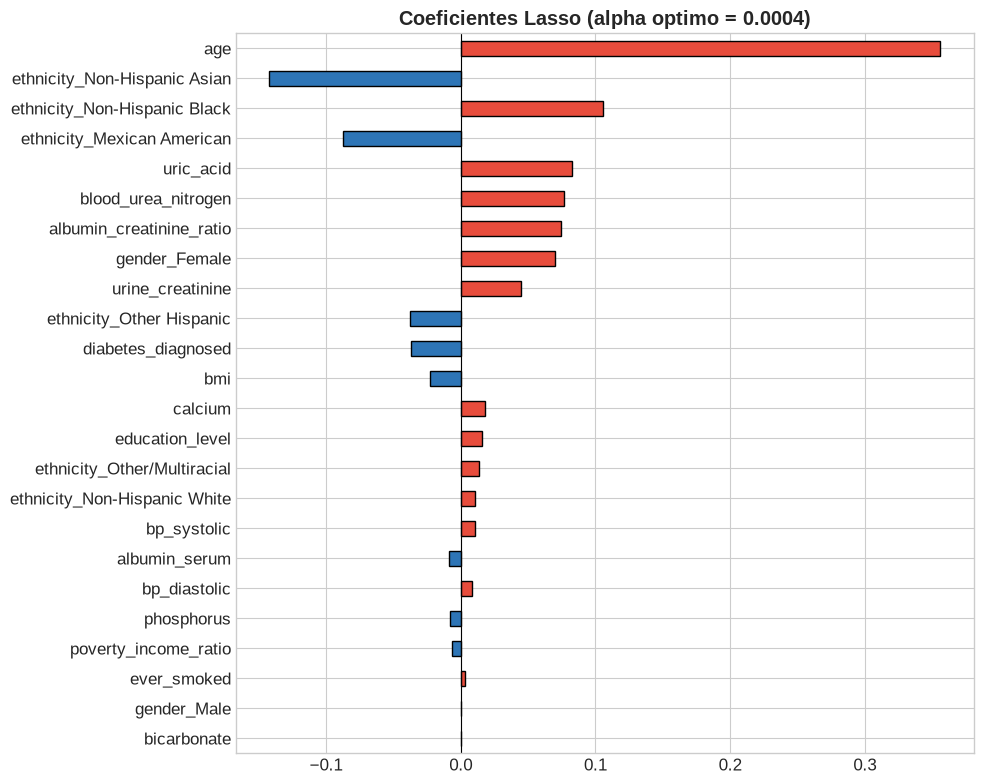


Alpha optimo: 0.000358

Variables DESCARTADAS (2): ['bicarbonate', 'gender_Male']

Variables RETENIDAS (22): ['ever_smoked', 'poverty_income_ratio', 'phosphorus', 'bp_diastolic', 'albumin_serum', 'bp_systolic', 'ethnicity_Non-Hispanic White', 'ethnicity_Other/Multiracial', 'education_level', 'calcium', 'bmi', 'diabetes_diagnosed', 'ethnicity_Other Hispanic', 'urine_creatinine', 'gender_Female', 'albumin_creatinine_ratio', 'blood_urea_nitrogen', 'uric_acid', 'ethnicity_Mexican American', 'ethnicity_Non-Hispanic Black', 'ethnicity_Non-Hispanic Asian', 'age']

Top 5 aporte: ['age', 'ethnicity_Non-Hispanic Asian', 'ethnicity_Non-Hispanic Black', 'ethnicity_Mexican American', 'uric_acid']


In [16]:
# =====================================================================
# LASSO: analisis exploratorio de importancia (regularizacion L1)
# =====================================================================
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

# Variables: numericas (con outliers) + categoricas codificadas
lasso_num = (
    df_labs.select_dtypes(include=[np.number])
    .drop(columns=["ckd_present"])
    .columns.tolist()
)
lasso_cat = df_labs.select_dtypes(include=["object", "str"]).columns.tolist()

prep_lasso = ColumnTransformer(
    [
        (
            "num",
            Pipeline(
                [("imp", SimpleImputer(strategy="median")), ("scl", RobustScaler())]
            ),
            lasso_num,
        ),
        (
            "cat",
            Pipeline(
                [
                    ("imp", SimpleImputer(strategy="most_frequent")),
                    (
                        "enc",
                        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                    ),
                ]
            ),
            lasso_cat,
        ),
    ]
)

X_lasso = prep_lasso.fit_transform(df_labs)
y_lasso = df_labs["ckd_present"].values

lasso = LassoCV(cv=5, random_state=42, max_iter=100000, n_jobs=-1)
lasso.fit(X_lasso, y_lasso)

feat_names = lasso_num + list(
    prep_lasso.named_transformers_["cat"]["enc"].get_feature_names_out(lasso_cat)
)
coef = pd.Series(lasso.coef_, index=feat_names).sort_values(key=lambda s: s.abs())

plt.figure(figsize=(10, 8))
colors = ["#E74C3C" if x > 0 else "#2E75B6" for x in coef.values]
coef.plot(kind="barh", color=colors, edgecolor="black")
plt.title(f"Coeficientes Lasso (alpha optimo = {lasso.alpha_:.4f})", fontweight="bold")
plt.axvline(0, color="black", lw=0.8)
plt.tight_layout()
plt.show()

print(f"\nAlpha optimo: {lasso.alpha_:.6f}")
desechables = coef[coef.abs() < 1e-8].index.tolist()
print(f"\nVariables DESCARTADAS ({len(desechables)}): {desechables}")
retenidas = coef[coef.abs() >= 1e-8].index.tolist()
print(f"\nVariables RETENIDAS ({len(retenidas)}): {retenidas}")
print(f"\nTop 5 aporte: {coef.abs().nlargest(5).index.tolist()}")

---
## FASE 5: Preprocesamiento, Split y Balanceo

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

X = df_labs.drop(columns=["ckd_present"])
y = df_labs["ckd_present"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} ({y_train.mean() * 100:.1f}% CKD)")
print(f"Test:  {X_test.shape[0]} ({y_test.mean() * 100:.1f}% CKD)")

Train: 4355 (48.1% CKD)
Test:  1089 (48.1% CKD)


In [18]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object", "str"]).columns.tolist()
print(f"Numericas ({len(numeric_cols)}): {numeric_cols}")
print(f"Categoricas ({len(categorical_cols)}): {categorical_cols}")

Numericas (16): ['age', 'education_level', 'poverty_income_ratio', 'bmi', 'bp_systolic', 'bp_diastolic', 'blood_urea_nitrogen', 'albumin_serum', 'phosphorus', 'bicarbonate', 'calcium', 'uric_acid', 'urine_creatinine', 'albumin_creatinine_ratio', 'diabetes_diagnosed', 'ever_smoked']
Categoricas (2): ['gender', 'ethnicity']


In [19]:
# Pipeline: KNNImputer + RobustScaler para numericas, OneHot para categoricas
numeric_pipeline = Pipeline(
    [("imputer", KNNImputer(n_neighbors=5)), ("scaler", RobustScaler())]
)

categorical_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ]
)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

cat_names = preprocessor.named_transformers_["cat"]["encoder"].get_feature_names_out(
    categorical_cols
)
all_features = list(numeric_cols) + list(cat_names)

print(f"Features: {X_train_prep.shape[1]}")
print(
    f"Nulos train: {np.isnan(X_train_prep).sum()} | Nulos test: {np.isnan(X_test_prep).sum()}"
)

Features: 24
Nulos train: 0 | Nulos test: 0


ANTES:  No CKD=2259 | CKD=2096
DESPUES: No CKD=2259 | CKD=2259


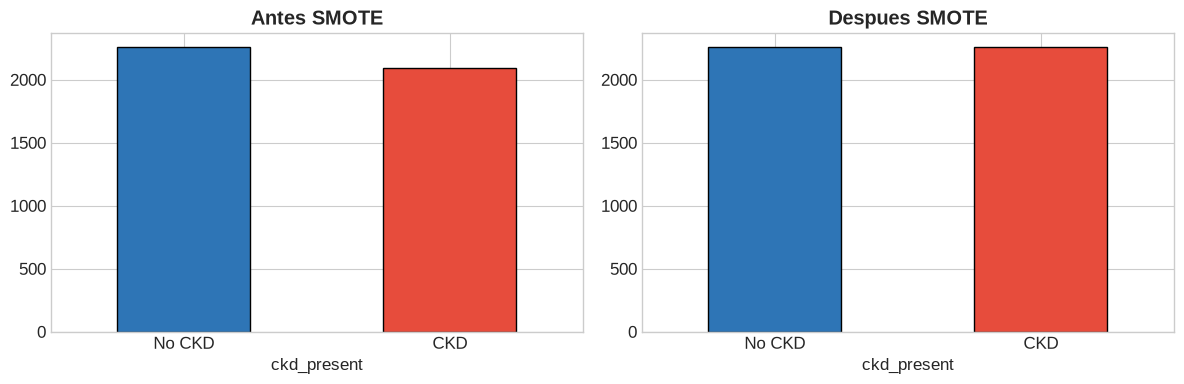

In [20]:
# SMOTE (solo en train)
from imblearn.over_sampling import SMOTE

print(f"ANTES:  No CKD={(y_train == 0).sum()} | CKD={(y_train == 1).sum()}")
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_prep, y_train)
print(f"DESPUES: No CKD={(y_train_bal == 0).sum()} | CKD={(y_train_bal == 1).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.Series(y_train).value_counts().plot(
    kind="bar", ax=axes[0], color=["#2E75B6", "#E74C3C"], edgecolor="black"
)
axes[0].set_title("Antes SMOTE", fontweight="bold")
axes[0].set_xticklabels(["No CKD", "CKD"], rotation=0)
pd.Series(y_train_bal).value_counts().plot(
    kind="bar", ax=axes[1], color=["#2E75B6", "#E74C3C"], edgecolor="black"
)
axes[1].set_title("Despues SMOTE", fontweight="bold")
axes[1].set_xticklabels(["No CKD", "CKD"], rotation=0)
plt.tight_layout()
plt.show()

---
## FASE 6: Entrenamiento de modelos base + Cross-Validation

In [21]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=15, random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    ),
}

# SMOTE DENTRO de cada fold (imblearn Pipeline): evita fuga entre folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    print(f"\n{'=' * 50}\n{name}\n{'=' * 50}")
    pipe = ImbPipeline([("smote", SMOTE(random_state=42)), ("clf", model)])
    auc = cross_val_score(
        pipe, X_train_prep, y_train, cv=cv, scoring="roc_auc", n_jobs=-1
    )
    f1 = cross_val_score(pipe, X_train_prep, y_train, cv=cv, scoring="f1", n_jobs=-1)
    acc = cross_val_score(
        pipe, X_train_prep, y_train, cv=cv, scoring="accuracy", n_jobs=-1
    )
    recall = cross_val_score(
        pipe, X_train_prep, y_train, cv=cv, scoring="recall", n_jobs=-1
    )

    results[name] = {
        "AUC-ROC": f"{auc.mean():.4f} (+/- {auc.std():.4f})",
        "F1": f"{f1.mean():.4f} (+/- {f1.std():.4f})",
        "Accuracy": f"{acc.mean():.4f} (+/- {acc.std():.4f})",
        "Recall": f"{recall.mean():.4f} (+/- {recall.std():.4f})",
        "AUC_mean": auc.mean(),
    }
    print(f"  AUC-ROC:  {auc.mean():.4f} (+/- {auc.std():.4f})")
    print(f"  F1:       {f1.mean():.4f} (+/- {f1.std():.4f})")
    print(f"  Accuracy: {acc.mean():.4f} (+/- {acc.std():.4f})")
    print(f"  Recall:   {recall.mean():.4f} (+/- {recall.std():.4f})")

pd.DataFrame(results).T.drop(columns=["AUC_mean"])


Logistic Regression
  AUC-ROC:  0.8650 (+/- 0.0149)
  F1:       0.7744 (+/- 0.0155)
  Accuracy: 0.7807 (+/- 0.0123)
  Recall:   0.7829 (+/- 0.0264)

Random Forest
  AUC-ROC:  0.8841 (+/- 0.0133)
  F1:       0.7917 (+/- 0.0139)
  Accuracy: 0.7991 (+/- 0.0112)
  Recall:   0.7939 (+/- 0.0238)

XGBoost
  AUC-ROC:  0.8831 (+/- 0.0120)
  F1:       0.7872 (+/- 0.0122)
  Accuracy: 0.7991 (+/- 0.0085)
  Recall:   0.7734 (+/- 0.0286)


,AUC-ROC,F1,Accuracy,Recall
Logistic Regression,0.8650 (+/- 0.0149),0.7744 (+/- 0.0155),0.7807 (+/- 0.0123),0.7829 (+/- 0.0264)
Random Forest,0.8841 (+/- 0.0133),0.7917 (+/- 0.0139),0.7991 (+/- 0.0112),0.7939 (+/- 0.0238)
XGBoost,0.8831 (+/- 0.0120),0.7872 (+/- 0.0122),0.7991 (+/- 0.0085),0.7734 (+/- 0.0286)


---
## FASE 7: Optimizacion de hiperparametros (GridSearchCV)

Random Forest y XGBoost estan muy cerca (~0.93 AUC). Con GridSearch buscamos la mejor combinacion de hiperparametros para cada uno.

In [22]:
import time

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV

# =============================================
# GRID SEARCH - RANDOM FOREST (SMOTE en cada fold)
# =============================================
print("=" * 60)
print("GRID SEARCH: Random Forest")
print("=" * 60)

rf_params = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [10, 15, 20, None],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
}

rf_grid = GridSearchCV(
    ImbPipeline(
        [
            ("smote", SMOTE(random_state=42)),
            ("clf", RandomForestClassifier(random_state=42, n_jobs=-1)),
        ]
    ),
    rf_params,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

t0 = time.time()
rf_grid.fit(X_train_prep, y_train)
t_rf = time.time() - t0

print(f"\nTiempo: {t_rf:.1f}s")
print(f"Mejor AUC-ROC: {rf_grid.best_score_:.4f}")
print(f"Mejores parametros: {rf_grid.best_params_}")

GRID SEARCH: Random Forest
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Tiempo: 77.2s
Mejor AUC-ROC: 0.8860
Mejores parametros: {'clf__max_depth': 15, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 10, 'clf__n_estimators': 400}


In [23]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# =============================================
# GRID SEARCH - XGBOOST (SMOTE en cada fold)
# =============================================
print("=" * 60)
print("GRID SEARCH: XGBoost")
print("=" * 60)

xgb_params = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [4, 6, 8],
    "clf__learning_rate": [0.05, 0.1, 0.2],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0],
}

xgb_grid = GridSearchCV(
    ImbPipeline(
        [
            ("smote", SMOTE(random_state=42)),
            (
                "clf",
                XGBClassifier(
                    use_label_encoder=False,
                    eval_metric="logloss",
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    xgb_params,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

t0 = time.time()
xgb_grid.fit(X_train_prep, y_train)
t_xgb = time.time() - t0

print(f"\nTiempo: {t_xgb:.1f}s")
print(f"Mejor AUC-ROC: {xgb_grid.best_score_:.4f}")
print(f"Mejores parametros: {xgb_grid.best_params_}")

GRID SEARCH: XGBoost
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Tiempo: 40.8s
Mejor AUC-ROC: 0.8961
Mejores parametros: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 200, 'clf__subsample': 0.8}


In [24]:
# =============================================
# COMPARACION: Base vs Optimizado
# =============================================
print("=" * 60)
print("COMPARACION: ANTES vs DESPUES de GridSearch")
print("=" * 60)
print("\nRandom Forest:")
print(f"  Base:       AUC = {results['Random Forest']['AUC_mean']:.4f}")
print(f"  Optimizado: AUC = {rf_grid.best_score_:.4f}")
print(
    f"  Mejora:     {(rf_grid.best_score_ - results['Random Forest']['AUC_mean']) * 100:+.2f}%"
)

print("\nXGBoost:")
print(f"  Base:       AUC = {results['XGBoost']['AUC_mean']:.4f}")
print(f"  Optimizado: AUC = {xgb_grid.best_score_:.4f}")
print(
    f"  Mejora:     {(xgb_grid.best_score_ - results['XGBoost']['AUC_mean']) * 100:+.2f}%"
)

# Elegir el mejor entre los dos optimizados
if rf_grid.best_score_ >= xgb_grid.best_score_:
    best_model = rf_grid.best_estimator_
    best_name = "Random Forest (optimizado)"
    best_auc_cv = rf_grid.best_score_
else:
    best_model = xgb_grid.best_estimator_
    best_name = "XGBoost (optimizado)"
    best_auc_cv = xgb_grid.best_score_

print(f"\n>>> MEJOR MODELO FINAL: {best_name} (AUC CV = {best_auc_cv:.4f})")

COMPARACION: ANTES vs DESPUES de GridSearch

Random Forest:
  Base:       AUC = 0.8841
  Optimizado: AUC = 0.8860
  Mejora:     +0.19%

XGBoost:
  Base:       AUC = 0.8831
  Optimizado: AUC = 0.8961
  Mejora:     +1.29%

>>> MEJOR MODELO FINAL: XGBoost (optimizado) (AUC CV = 0.8961)


---
## FASE 8: Evaluacion final en Test Set

In [25]:
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

# Predecir en TEST
y_pred = best_model.predict(X_test_prep)
y_prob = best_model.predict_proba(X_test_prep)[:, 1]

print(f"Modelo: {best_name}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"AUC-PR:  {average_precision_score(y_test, y_prob):.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['No CKD', 'CKD'])}")

Modelo: XGBoost (optimizado)
AUC-ROC: 0.8791
AUC-PR:  0.8867

              precision    recall  f1-score   support

      No CKD       0.80      0.80      0.80       565
         CKD       0.79      0.78      0.78       524

    accuracy                           0.79      1089
   macro avg       0.79      0.79      0.79      1089
weighted avg       0.79      0.79      0.79      1089



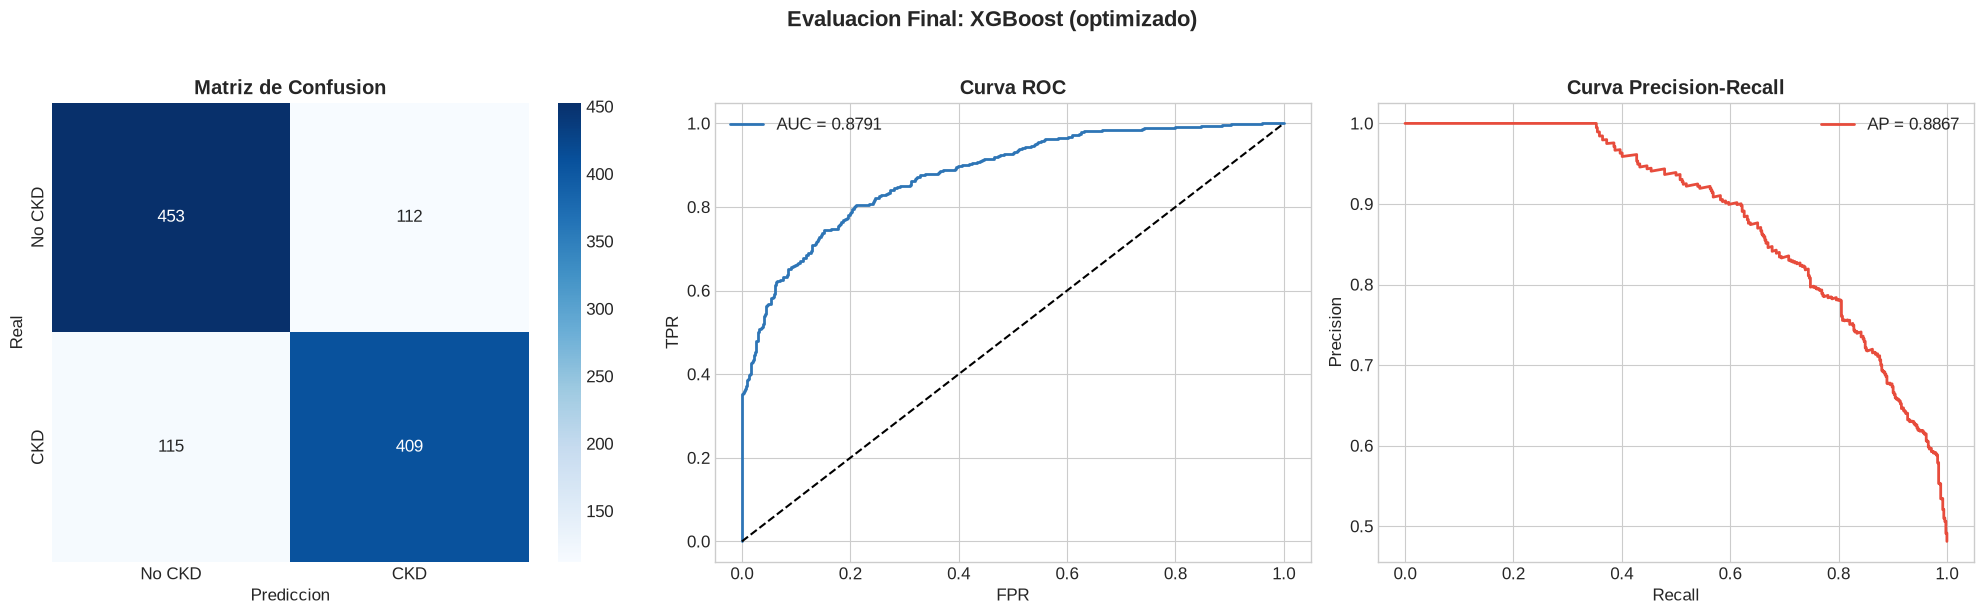

In [26]:
# Confusion matrix + ROC + PR
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=["No CKD", "CKD"],
    yticklabels=["No CKD", "CKD"],
)
axes[0].set_xlabel("Prediccion")
axes[0].set_ylabel("Real")
axes[0].set_title("Matriz de Confusion", fontweight="bold")

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(
    fpr,
    tpr,
    color="#2E75B6",
    linewidth=2,
    label=f"AUC = {roc_auc_score(y_test, y_prob):.4f}",
)
axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].set_title("Curva ROC", fontweight="bold")
axes[1].legend()

prec, rec, _ = precision_recall_curve(y_test, y_prob)
axes[2].plot(
    rec,
    prec,
    color="#E74C3C",
    linewidth=2,
    label=f"AP = {average_precision_score(y_test, y_prob):.4f}",
)
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Curva Precision-Recall", fontweight="bold")
axes[2].legend()

plt.suptitle(f"Evaluacion Final: {best_name}", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Analisis de sensibilidad: dependencia de las variables de definicion
ACR >= 30 es criterio diagnostico de CKD (KDIGO) -> fuga parcial.
Reentrenamos XGBoost sin `albumin_creatinine_ratio`
sobre el MISMO split y cuantificamos la caida de AUC.

X_sens: 17 variables (sin 1 de definicion)

AUC-ROC con ACR:      0.8791
AUC-ROC sin ACR:      0.8186
Caida:                0.0605 (6.9%)
AUC-PR con ACR:       0.8867
AUC-PR sin ACR:       0.8223

CONCLUSION: AUC sin ACR < 0.85 -> dependencia relevante de la fuga;
reportar que parte del desempeno viene de ACR.


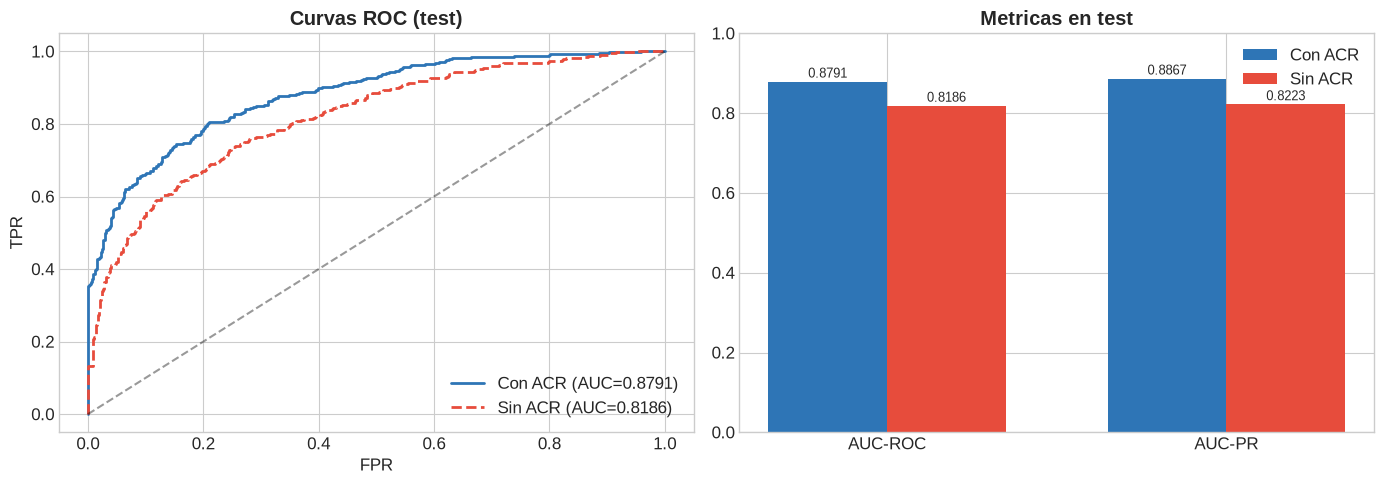

In [27]:
# =====================================================================
# ANALISIS DE SENSIBILIDAD: XGBoost SIN variables de definicion de CKD
# =====================================================================
vars_fuga = ["albumin_creatinine_ratio"]

X_sens = df_labs.drop(columns=["ckd_present"] + vars_fuga)
print(f"X_sens: {X_sens.shape[1]} variables (sin {len(vars_fuga)} de definicion)")

# Mismo split (random_state=42, stratify) -> los mismos pacientes en test
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sens, y, test_size=0.2, random_state=42, stratify=y
)

# Recalcular preprocesador porque cambiaron las columnas
numeric_s = X_train_s.select_dtypes(include=[np.number]).columns.tolist()
categorical_s = X_train_s.select_dtypes(include=["object", "str"]).columns.tolist()

prep_sens = ColumnTransformer(
    [
        (
            "num",
            Pipeline(
                [("imputer", KNNImputer(n_neighbors=5)), ("scaler", RobustScaler())]
            ),
            numeric_s,
        ),
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "encoder",
                        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                    ),
                ]
            ),
            categorical_s,
        ),
    ]
)

X_train_s_prep = prep_sens.fit_transform(X_train_s)
X_test_s_prep = prep_sens.transform(X_test_s)

# SMOTE sobre el nuevo train
smote_s = SMOTE(random_state=42)
X_train_s_bal, y_train_s_bal = smote_s.fit_resample(X_train_s_prep, y_train_s)

# XGBoost con los mismos hiperparametros del grid (quitar prefijo clf__)
xgb_params_s = {k.replace("clf__", ""): v for k, v in xgb_grid.best_params_.items()}
xgb_sens = XGBClassifier(**xgb_params_s)
xgb_sens.fit(X_train_s_bal, y_train_s_bal)

# Evaluar en el MISMO test
prob_sens = xgb_sens.predict_proba(X_test_s_prep)[:, 1]
auc_sens = roc_auc_score(y_test_s, prob_sens)
ap_sens = average_precision_score(y_test_s, prob_sens)

# AUC con ACR: MISMO modelo (XGBoost optimizado) y mismo test
xgb_prob = xgb_grid.best_estimator_.predict_proba(X_test_prep)[:, 1]
auc_full = roc_auc_score(y_test, xgb_prob)
ap_full = average_precision_score(y_test, xgb_prob)

caida = auc_full - auc_sens
print(f"\nAUC-ROC con ACR:      {auc_full:.4f}")
print(f"AUC-ROC sin ACR:      {auc_sens:.4f}")
print(f"Caida:                {caida:.4f} ({caida / auc_full * 100:.1f}%)")
print(f"AUC-PR con ACR:       {ap_full:.4f}")
print(f"AUC-PR sin ACR:       {ap_sens:.4f}")

if auc_sens >= 0.85:
    print("\nCONCLUSION: AUC sin ACR >= 0.85 -> el modelo NO depende de la fuga;")
    print("aprende patrones renales genuinos.")
else:
    print("\nCONCLUSION: AUC sin ACR < 0.85 -> dependencia relevante de la fuga;")
    print("reportar que parte del desempeno viene de ACR.")

# Grafico: ROC superpuestas + barras comparativas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr_f, tpr_f, _ = roc_curve(y_test, xgb_prob)
fpr_s, tpr_s, _ = roc_curve(y_test_s, prob_sens)
axes[0].plot(fpr_f, tpr_f, color="#2E75B6", lw=2, label=f"Con ACR (AUC={auc_full:.4f})")
axes[0].plot(
    fpr_s,
    tpr_s,
    color="#E74C3C",
    lw=2,
    ls="--",
    label=f"Sin ACR (AUC={auc_sens:.4f})",
)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].set_title("Curvas ROC (test)", fontweight="bold")
axes[0].legend()

labels = ["AUC-ROC", "AUC-PR"]
vals_con = [auc_full, ap_full]
vals_sin = [auc_sens, ap_sens]
x = np.arange(2)
w = 0.35
b1 = axes[1].bar(x - w / 2, vals_con, w, color="#2E75B6", label="Con ACR")
b2 = axes[1].bar(x + w / 2, vals_sin, w, color="#E74C3C", label="Sin ACR")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylim(0, 1)
axes[1].set_title("Metricas en test", fontweight="bold")
axes[1].legend()
for bars in (b1, b2):
    for b in bars:
        axes[1].text(
            b.get_x() + b.get_width() / 2,
            b.get_height() + 0.01,
            f"{b.get_height():.4f}",
            ha="center",
            fontsize=9,
        )
plt.tight_layout()
plt.show()

---
## FASE 9: Interpretabilidad con SHAP

In [28]:
import shap

# TreeExplainer para modelos basados en arboles
explainer = shap.TreeExplainer(best_model.named_steps["clf"])
shap_values = explainer.shap_values(X_test_prep)

# Ajustar segun tipo
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
    base_val = explainer.expected_value[1]
else:
    shap_vals = shap_values
    base_val = explainer.expected_value

print(f"SHAP values: {shap_vals.shape}")

SHAP values: (1089, 24)


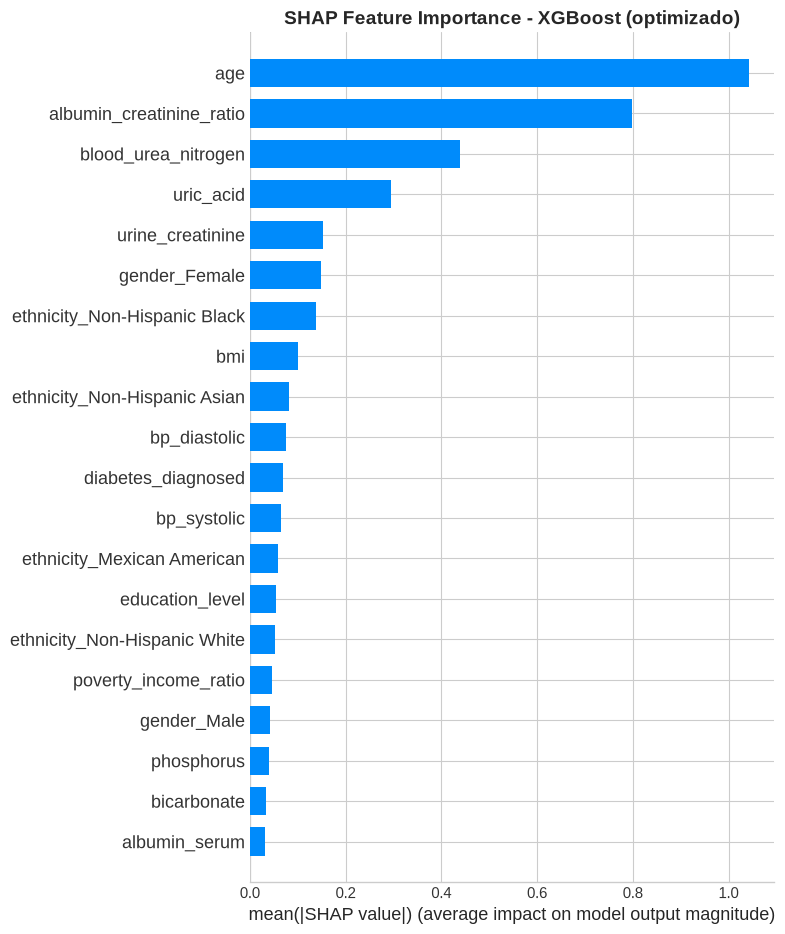

In [29]:
# Bar plot (importancia global)
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_vals,
    X_test_prep,
    feature_names=all_features,
    plot_type="bar",
    show=False,
    max_display=20,
)
plt.title(f"SHAP Feature Importance - {best_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

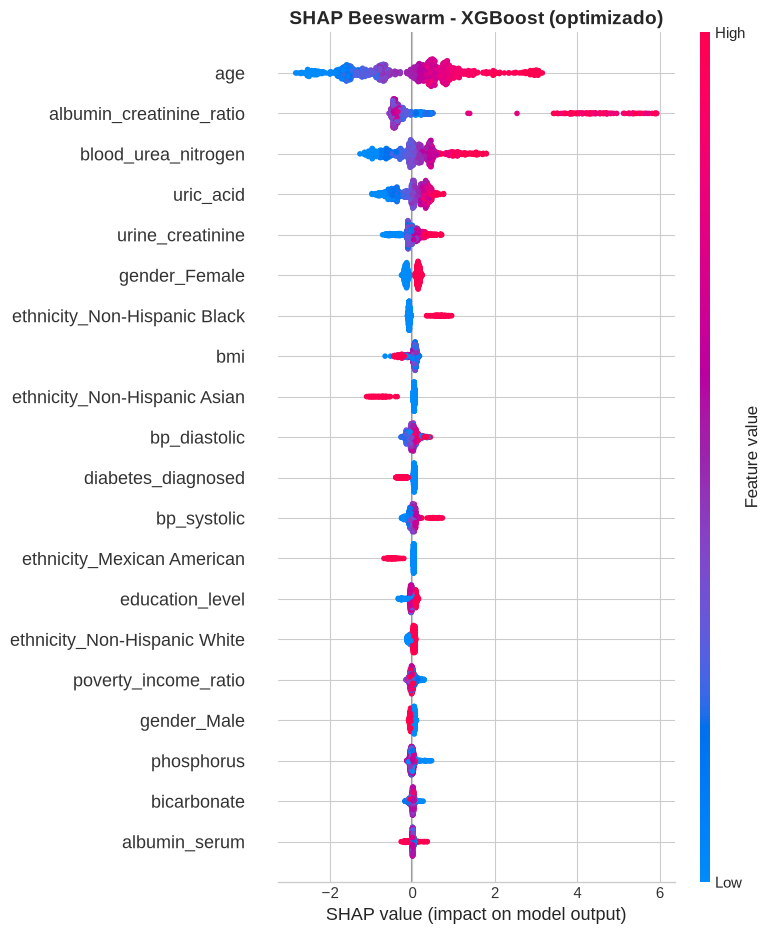

In [30]:
# Beeswarm plot (importancia + direccion)
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_vals, X_test_prep, feature_names=all_features, show=False, max_display=20
)
plt.title(f"SHAP Beeswarm - {best_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [31]:
# Top 10 features
shap_importance = pd.DataFrame(
    {"Feature": all_features, "Mean |SHAP|": np.abs(shap_vals).mean(axis=0)}
).sort_values("Mean |SHAP|", ascending=False)

print("Top 10 variables (SHAP):")
print("=" * 55)
for _, row in shap_importance.head(10).iterrows():
    bar = "█" * int(row["Mean |SHAP|"] / shap_importance["Mean |SHAP|"].max() * 25)
    print(f"  {row['Feature']:35s} {row['Mean |SHAP|']:.4f}  {bar}")

Top 10 variables (SHAP):
  age                                 1.0429  █████████████████████████
  albumin_creatinine_ratio            0.7986  ███████████████████
  blood_urea_nitrogen                 0.4394  ██████████
  uric_acid                           0.2959  ███████
  urine_creatinine                    0.1525  ███
  gender_Female                       0.1477  ███
  ethnicity_Non-Hispanic Black        0.1380  ███
  bmi                                 0.1002  ██
  ethnicity_Non-Hispanic Asian        0.0811  █
  bp_diastolic                        0.0758  █


Paciente con CKD | Prob: 0.9895 | Real: CKD=1


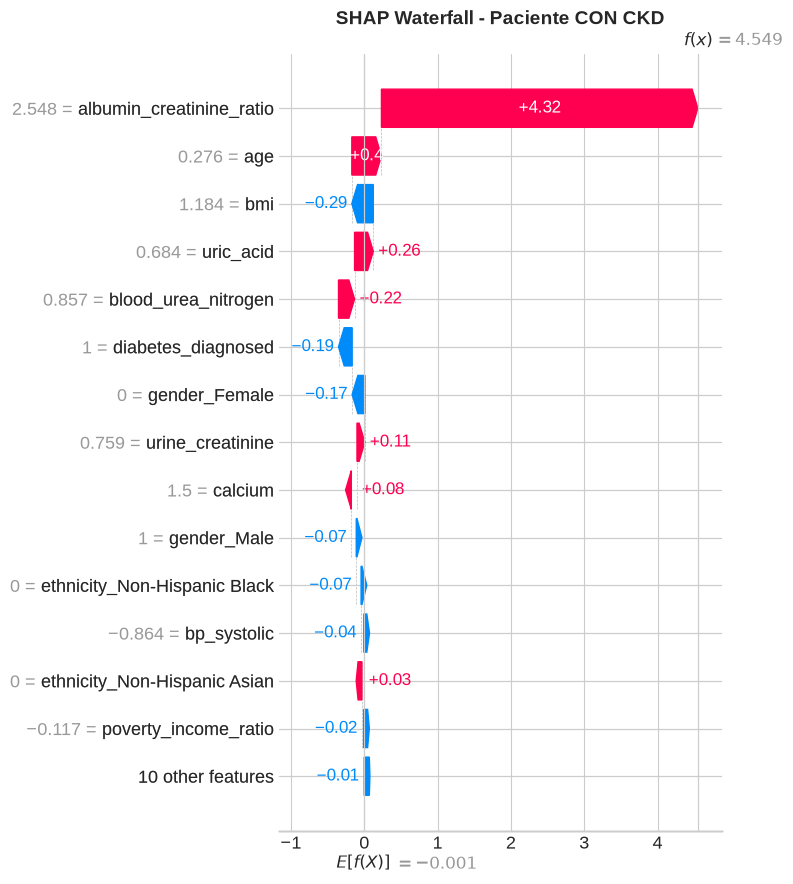

In [32]:
# Waterfall: paciente CON CKD
idx_ckd = np.where(y_test.values == 1)[0][0]
print(
    f"Paciente con CKD | Prob: {y_prob[idx_ckd]:.4f} | Real: CKD={y_test.iloc[idx_ckd]}"
)

expl_ckd = shap.Explanation(
    values=shap_vals[idx_ckd],
    base_values=base_val,
    data=X_test_prep[idx_ckd],
    feature_names=all_features,
)
plt.figure(figsize=(12, 8))
shap.plots.waterfall(expl_ckd, show=False, max_display=15)
plt.title("SHAP Waterfall - Paciente CON CKD", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Paciente sin CKD | Prob: 0.0787 | Real: CKD=0


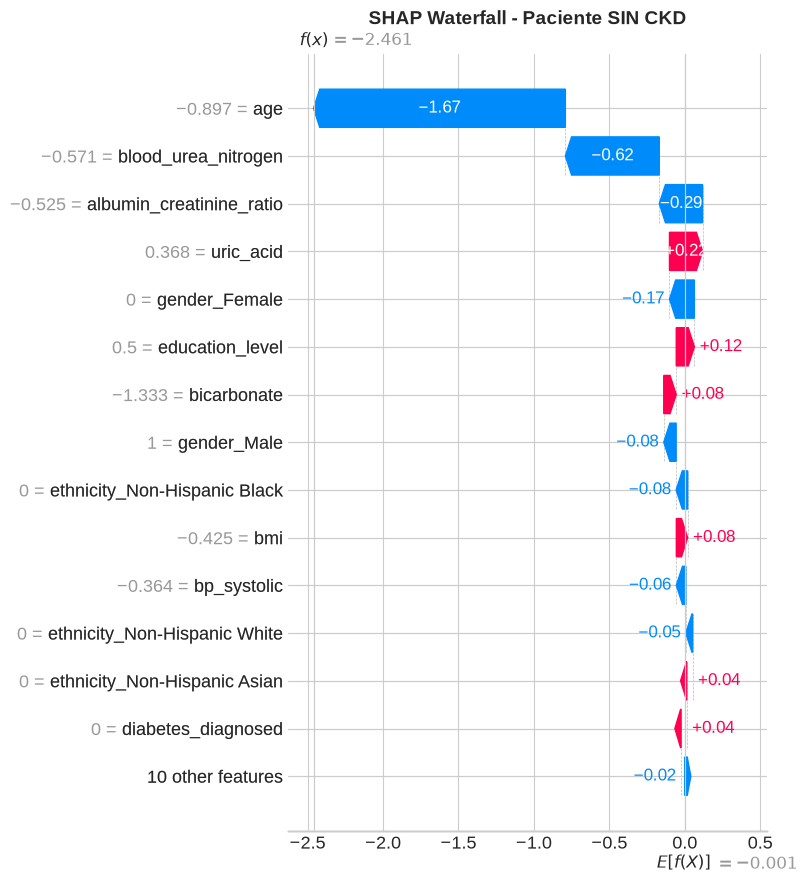

In [33]:
# Waterfall: paciente SIN CKD
idx_no = np.where(y_test.values == 0)[0][0]
print(
    f"Paciente sin CKD | Prob: {y_prob[idx_no]:.4f} | Real: CKD={y_test.iloc[idx_no]}"
)

expl_no = shap.Explanation(
    values=shap_vals[idx_no],
    base_values=base_val,
    data=X_test_prep[idx_no],
    feature_names=all_features,
)
plt.figure(figsize=(12, 8))
shap.plots.waterfall(expl_no, show=False, max_display=15)
plt.title("SHAP Waterfall - Paciente SIN CKD", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## FASE 9: Redes Neuronales (TensorFlow/Keras)

Comparacion de dos arquitecturas de redes neuronales para clasificar ERC:

- **Somera**: 1 capa oculta (64 neuronas)
- **Profunda**: 4 capas ocultas (128-64-32-16)

Ambas se entrenan sobre los datos balanceados con SMOTE (`X_train_bal`), con 200 epochs, **EarlyStopping** y **decay exponencial** del learning rate. Metrica de evaluacion: **accuracy**.

In [34]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import callbacks, layers, models, optimizers
from tensorflow.keras.optimizers.schedules import ExponentialDecay

tf.random.set_seed(42)
np.random.seed(42)
print("TensorFlow:", tf.__version__)
print("X_train_bal:", X_train_bal.shape, "| y_train_bal:", y_train_bal.shape)
print("X_test_prep:", X_test_prep.shape, "| y_test:", y_test.shape)

I0000 00:00:1786920560.688428  238143 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786920560.688907  238143 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786920560.719941  238143 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0
X_train_bal: (4518, 24) | y_train_bal: (4518,)
X_test_prep: (1089, 24) | y_test: (1089,)


I0000 00:00:1786920561.706657  238143 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786920561.707051  238143 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [35]:
# =====================================================================
# Configuracion compartida: EarlyStopping + decay exponencial
# =====================================================================
BATCH = 32
EPOCHS = 200
VAL_SPLIT = 0.2

decay_steps = int((len(X_train_bal) * (1 - VAL_SPLIT)) // BATCH)

lr_schedule = ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=decay_steps,
    decay_rate=0.9,
    staircase=True,
)

early_stop = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=15,
    min_delta=1e-4,
    restore_best_weights=True,
    verbose=1,
)

print(
    f"Decay steps/epoch: {decay_steps} | lr inicial: {lr_schedule.initial_learning_rate}"
)

Decay steps/epoch: 112 | lr inicial: 0.001


In [36]:
# =====================================================================
# ARQUITECTURA SOMERA: 1 capa oculta (64 neuronas)
# =====================================================================
shallow = models.Sequential(
    [
        layers.Input(shape=(X_train_bal.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ]
)

shallow.compile(
    optimizer=optimizers.Adam(learning_rate=lr_schedule),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
shallow.summary()

shallow.fit(
    X_train_bal,
    y_train_bal,
    batch_size=BATCH,
    epochs=EPOCHS,
    validation_split=VAL_SPLIT,
    callbacks=[early_stop],
    verbose=2,
)

E0000 00:00:1786920561.841626  238143 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1786920561.870000  238143 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,665 (6.50 KB)

 Trainable params: 1,665 (6.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
113/113 - 1s - 7ms/step - accuracy: 0.6157 - loss: 0.6450 - val_accuracy: 0.7268 - val_loss: 0.5413
Epoch 2/200
113/113 - 0s - 1ms/step - accuracy: 0.7468 - loss: 0.5052 - val_accuracy: 0.7412 - val_loss: 0.4939
Epoch 3/200
113/113 - 0s - 1ms/step - accuracy: 0.7665 - loss: 0.4710 - val_accuracy: 0.7600 - val_loss: 0.4779
Epoch 4/200
113/113 - 0s - 1ms/step - accuracy: 0.7745 - loss: 0.4654 - val_accuracy: 0.7677 - val_loss: 0.4708
Epoch 5/200
113/113 - 0s - 1ms/step - accuracy: 0.7770 - loss: 0.4594 - val_accuracy: 0.7710 - val_loss: 0.4631
Epoch 6/200
113/113 - 0s - 1ms/step - accuracy: 0.7775 - loss: 0.4536 - val_accuracy: 0.7743 - val_loss: 0.4589
Epoch 7/200
113/113 - 0s - 1ms/step - accuracy: 0.7903 - loss: 0.4476 - val_accuracy: 0.7788 - val_loss: 0.4539
Epoch 8/200
113/113 - 0s - 1ms/step - accuracy: 0.7889 - loss: 0.4404 - val_accuracy: 0.7788 - val_loss: 0.4507
Epoch 9/200
113/113 - 0s - 1ms/step - accuracy: 0.7925 - loss: 0.4452 - val_accuracy: 0.7788 - val_loss:

In [37]:
# =====================================================================
# ARQUITECTURA PROFUNDA: 4 capas ocultas (128-64-32-16)
# =====================================================================
deep = models.Sequential(
    [
        layers.Input(shape=(X_train_bal.shape[1],)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ]
)

deep.compile(
    optimizer=optimizers.Adam(learning_rate=lr_schedule),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
deep.summary()

deep.fit(
    X_train_bal,
    y_train_bal,
    batch_size=BATCH,
    epochs=EPOCHS,
    validation_split=VAL_SPLIT,
    callbacks=[early_stop],
    verbose=2,
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,081 (55.00 KB)

 Trainable params: 14,081 (55.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
113/113 - 1s - 9ms/step - accuracy: 0.7244 - loss: 0.5485 - val_accuracy: 0.7788 - val_loss: 0.4652
Epoch 2/200
113/113 - 0s - 2ms/step - accuracy: 0.7919 - loss: 0.4602 - val_accuracy: 0.8020 - val_loss: 0.4339
Epoch 3/200
113/113 - 0s - 2ms/step - accuracy: 0.8066 - loss: 0.4331 - val_accuracy: 0.8075 - val_loss: 0.4220
Epoch 4/200
113/113 - 0s - 2ms/step - accuracy: 0.8157 - loss: 0.4094 - val_accuracy: 0.8042 - val_loss: 0.4181
Epoch 5/200
113/113 - 0s - 2ms/step - accuracy: 0.8251 - loss: 0.3976 - val_accuracy: 0.8042 - val_loss: 0.4195
Epoch 6/200
113/113 - 0s - 2ms/step - accuracy: 0.8276 - loss: 0.3834 - val_accuracy: 0.8075 - val_loss: 0.4237
Epoch 7/200
113/113 - 0s - 2ms/step - accuracy: 0.8356 - loss: 0.3713 - val_accuracy: 0.8097 - val_loss: 0.4304
Epoch 8/200
113/113 - 0s - 2ms/step - accuracy: 0.8384 - loss: 0.3682 - val_accuracy: 0.8053 - val_loss: 0.4218
Epoch 9/200
113/113 - 0s - 2ms/step - accuracy: 0.8453 - loss: 0.3563 - val_accuracy: 0.8075 - val_loss:


===== Somera (1 capa) =====
AUC-ROC TEST: 0.8587
Accuracy TEST: 0.7704
              precision    recall  f1-score   support

           0     0.7828    0.7717    0.7772       565
           1     0.7575    0.7691    0.7633       524

    accuracy                         0.7704      1089
   macro avg     0.7701    0.7704    0.7702      1089
weighted avg     0.7706    0.7704    0.7705      1089

Matriz de confusion:
[[436 129]
 [121 403]]

===== Profunda (4 capas) =====
AUC-ROC TEST: 0.8662
Accuracy TEST: 0.7778
              precision    recall  f1-score   support

           0     0.7818    0.7929    0.7873       565
           1     0.7733    0.7615    0.7673       524

    accuracy                         0.7778      1089
   macro avg     0.7776    0.7772    0.7773      1089
weighted avg     0.7777    0.7778    0.7777      1089

Matriz de confusion:
[[448 117]
 [125 399]]

===== Logistic Reg. =====
AUC-ROC TEST: 0.8346
Accuracy TEST: 0.7447

===== Random Forest (tuned) =====
AUC-RO

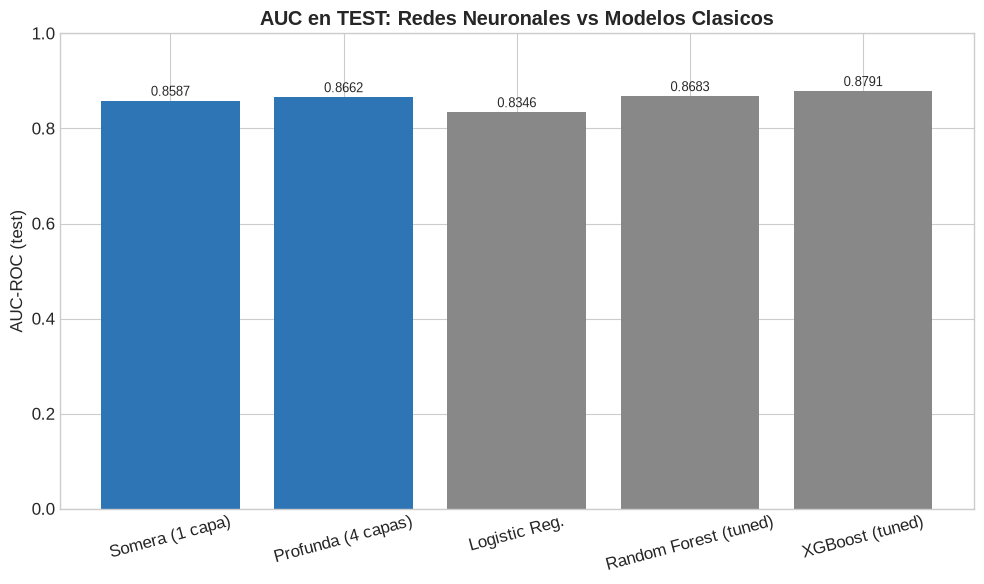


=== COMPARACION EN TEST (misma metrica, mismo conjunto) ===
                       AUC-ROC (test)  Accuracy (test)
XGBoost (tuned)                0.8791           0.7916
Random Forest (tuned)          0.8683           0.7750
Profunda (4 capas)             0.8662           0.7778
Somera (1 capa)                0.8587           0.7704
Logistic Reg.                  0.8346           0.7447


In [38]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

# =====================================================================
# Evaluacion en TEST: AUC-ROC para las 5 arquitecturas (misma metrica,
# mismo conjunto de test). Comparacion manzanas con manzanas.
# =====================================================================
nombres_nn = {"Somera (1 capa)": shallow, "Profunda (4 capas)": deep}
comparacion = {}

for nombre, model in nombres_nn.items():
    proba = model.predict(X_test_prep, verbose=0)
    y_pred = (proba >= 0.5).astype(int).ravel()
    comparacion[nombre] = {
        "AUC-test": roc_auc_score(y_test, proba.ravel()),
        "Acc-test": accuracy_score(y_test, y_pred),
    }
    print(f"\n===== {nombre} =====")
    print(f"AUC-ROC TEST: {comparacion[nombre]['AUC-test']:.4f}")
    print(f"Accuracy TEST: {comparacion[nombre]['Acc-test']:.4f}")
    print(classification_report(y_test, y_pred, digits=4))
    print("Matriz de confusion:")
    print(confusion_matrix(y_test, y_pred))

# Clasicos: predict_proba sobre el MISMO test set
clasicos = {
    "Logistic Reg.": LogisticRegression(max_iter=1000, random_state=42).fit(
        X_train_bal, y_train_bal
    ),
    "Random Forest (tuned)": rf_grid.best_estimator_,
    "XGBoost (tuned)": xgb_grid.best_estimator_,
}
for nombre, model in clasicos.items():
    proba = model.predict_proba(X_test_prep)[:, 1]
    y_pred = (proba >= 0.5).astype(int)
    comparacion[nombre] = {
        "AUC-test": roc_auc_score(y_test, proba),
        "Acc-test": accuracy_score(y_test, y_pred),
    }
    print(f"\n===== {nombre} =====")
    print(f"AUC-ROC TEST: {comparacion[nombre]['AUC-test']:.4f}")
    print(f"Accuracy TEST: {comparacion[nombre]['Acc-test']:.4f}")

# Grafica comparativa: AUC en TEST para las 5
plt.figure(figsize=(10, 6))
names = list(comparacion.keys())
vals = [comparacion[n]["AUC-test"] for n in names]
colors = ["#2E75B6" if i < 2 else "#888" for i in range(len(names))]
bars = plt.bar(names, vals, color=colors)
plt.ylim(0, 1)
plt.ylabel("AUC-ROC (test)")
plt.title("AUC en TEST: Redes Neuronales vs Modelos Clasicos", fontweight="bold")
for bar, v in zip(bars, vals):
    plt.text(
        bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.4f}", ha="center", fontsize=9
    )
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Tabla comparativa
tabla = pd.DataFrame(comparacion).T.round(4)
tabla.columns = ["AUC-ROC (test)", "Accuracy (test)"]
print("\n=== COMPARACION EN TEST (misma metrica, mismo conjunto) ===")
print(tabla.sort_values("AUC-ROC (test)", ascending=False))

VALIDACION: 3484 train + 871 val | CKD val: 0.481

=== UMBRALES CALCULADOS EN VALIDACION ===
Umbral           Valor    Sens    Spec
Youden J         0.415   0.847   0.754
Clinico          0.391   0.852   0.737

=== COMPARACION EN TEST (probabilidades del modelo original) ===
                      Valor   Sens   Spec     F1   FN   FP
Umbral                                                    
Default (0.50)        0.500  0.781  0.802  0.783  115  112
Youden                0.415  0.842  0.726  0.788   83  155
Clinico (sens>=0.85)  0.391  0.849  0.704  0.783   79  167


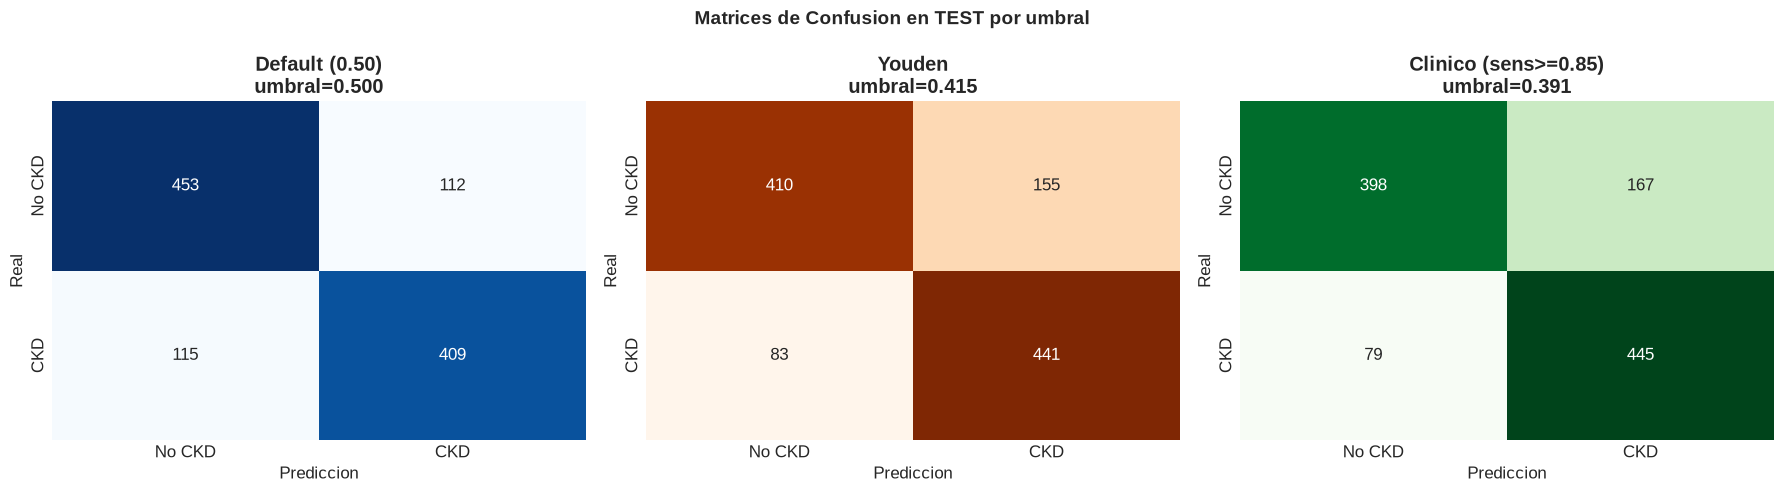

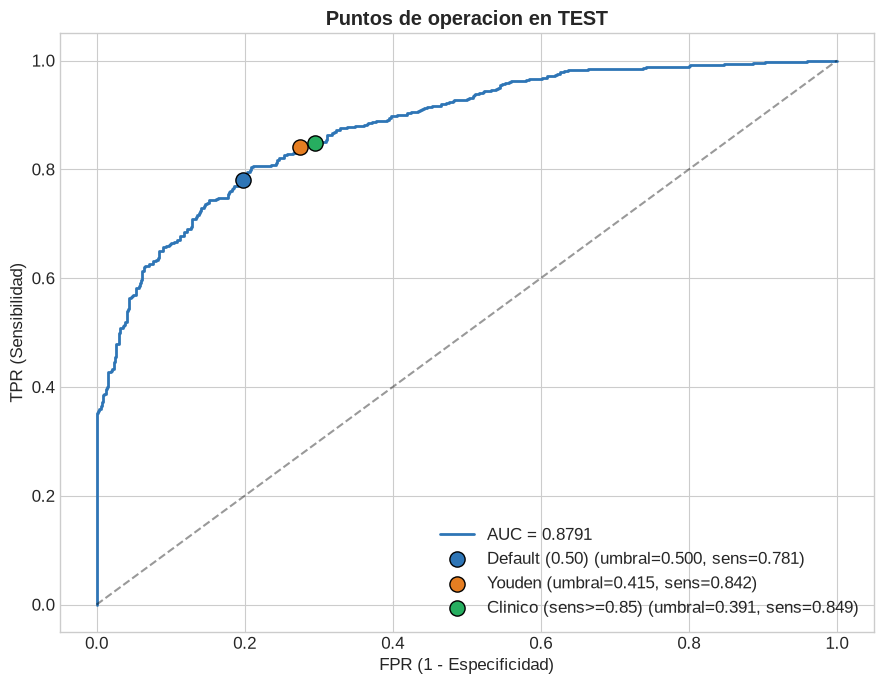


=== CONCLUSION (screening preventivo) ===
Umbral clinico vs default: 36 falsos negativos MENOS (115.0 -> 79.0) a cambio de 55 falsos positivos adicionales (112.0 -> 167.0).
En screening es el intercambio correcto: un FN es un enfermo que se va
a casa sin tratamiento; un FP solo genera una confirmacion adicional.


In [39]:
# =====================================================================
# OPTIMIZACION DE UMBRAL: enfoque PREVENTIVO de screening
# En screening es mas barato mandar a un sano a confirmarse (FP barato)
# que decirle a un enfermo que esta sano (FN costoso). El umbral se
# elige en VALIDACION (pre-SMOTE) y se aplica al test UNA sola vez.
# =====================================================================
from sklearn.model_selection import train_test_split

# SUPUESTO EXPLICITO: XGBoost es el mejor modelo hallado en el GridSearch.
# Los umbrales se calibran con XGBoost en validacion y se aplican a y_prob
# del mejor modelo (celda 38). Si best_model no fuera XGBoost, esta
# calibracion no seria transferible.
if best_name != "XGBoost (optimizado)":
    print(f"AVISO: best_model = {best_name}; el ajuste de umbral supone XGBoost")

# 1) Validacion del train PRE-SMOTE (desbalanceado ~43%, como el test)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_prep, y_train, test_size=0.2, stratify=y_train, random_state=42
)
print(
    f"VALIDACION: {len(X_tr)} train + {len(X_val)} val | "
    f"CKD val: {(y_val == 1).mean():.3f}"
)

# 2) SMOTE SOLO sobre el 80% de train
smote_v = SMOTE(random_state=42)
X_tr_bal, y_tr_bal = smote_v.fit_resample(X_tr, y_tr)

# 3) Re-entrenar XGBoost con los hiperparametros optimos del grid
xgb_params_f = {k.replace("clf__", ""): v for k, v in xgb_grid.best_params_.items()}
xgb_thr = XGBClassifier(**xgb_params_f)
xgb_thr.fit(X_tr_bal, y_tr_bal)

# 4) Curva ROC sobre VALIDACION para elegir umbrales
val_prob = xgb_thr.predict_proba(X_val)[:, 1]
fpr_v, tpr_v, thr_v = roc_curve(y_val, val_prob)

# Youden's J: maximiza sens + spec
j_idx = int(np.argmax(tpr_v - fpr_v))
thr_youden = float(thr_v[j_idx])
# Clinico: sens >= 0.85 maximizando especificidad
mask = tpr_v >= 0.85
c_idx = int(np.argmin(fpr_v[mask]))
thr_clin = float(thr_v[mask][c_idx])

print("\n=== UMBRALES CALCULADOS EN VALIDACION ===")
print(f"{'Umbral':<14}{'Valor':>8}{'Sens':>8}{'Spec':>8}")
print(f"{'Youden J':<14}{thr_youden:>8.3f}{tpr_v[j_idx]:>8.3f}{1 - fpr_v[j_idx]:>8.3f}")
print(
    f"{'Clinico':<14}{thr_clin:>8.3f}"
    f"{tpr_v[mask][c_idx]:>8.3f}{1 - fpr_v[mask][c_idx]:>8.3f}"
)

# 5) Aplicar los 3 umbrales al TEST con y_prob del modelo original
umbrales = {
    "Default (0.50)": 0.5,
    "Youden": thr_youden,
    "Clinico (sens>=0.85)": thr_clin,
}
filas = []
for nombre, umbral in umbrales.items():
    y_pred = (y_prob >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    f1 = 2 * tp / (2 * tp + fp + fn)
    filas.append(
        {
            "Umbral": nombre,
            "Valor": umbral,
            "Sens": sens,
            "Spec": spec,
            "F1": f1,
            "FN": fn,
            "FP": fp,
        }
    )

tabla_umbral = pd.DataFrame(filas).set_index("Umbral").round(3)
print("\n=== COMPARACION EN TEST (probabilidades del modelo original) ===")
print(tabla_umbral)

# 6) Grafico: 3 matrices de confusion lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmaps = ["Blues", "Oranges", "Greens"]
for ax, (nombre, umbral), cmap in zip(axes, umbrales.items(), cmaps):
    y_pred = (y_prob >= umbral).astype(int)
    sns.heatmap(
        confusion_matrix(y_test, y_pred),
        annot=True,
        fmt="d",
        cmap=cmap,
        ax=ax,
        xticklabels=["No CKD", "CKD"],
        yticklabels=["No CKD", "CKD"],
        cbar=False,
    )
    ax.set_title(f"{nombre}\numbral={umbral:.3f}", fontweight="bold")
    ax.set_xlabel("Prediccion")
    ax.set_ylabel("Real")
plt.suptitle("Matrices de Confusion en TEST por umbral", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 7) Curva ROC del test con los puntos de operacion
fpr_t, tpr_t, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(9, 7))
plt.plot(
    fpr_t,
    tpr_t,
    color="#2E75B6",
    lw=2,
    label=f"AUC = {roc_auc_score(y_test, y_prob):.4f}",
)
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
colores_pt = {
    "Default (0.50)": "#2E75B6",
    "Youden": "#E67E22",
    "Clinico (sens>=0.85)": "#27AE60",
}
for nombre, umbral in umbrales.items():
    y_pred = (y_prob >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    plt.scatter(
        1 - spec,
        sens,
        s=120,
        zorder=5,
        color=colores_pt[nombre],
        edgecolor="black",
        label=f"{nombre} (umbral={umbral:.3f}, sens={sens:.3f})",
    )
plt.xlabel("FPR (1 - Especificidad)")
plt.ylabel("TPR (Sensibilidad)")
plt.title("Puntos de operacion en TEST", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

# 8) Conclusion
default = tabla_umbral.loc["Default (0.50)"]
clin = tabla_umbral.loc["Clinico (sens>=0.85)"]
fn_ahorro = int(default["FN"] - clin["FN"])
fp_extra = int(clin["FP"] - default["FP"])
print("\n=== CONCLUSION (screening preventivo) ===")
print(
    f"Umbral clinico vs default: {fn_ahorro} falsos negativos MENOS "
    f"({default['FN']} -> {clin['FN']}) a cambio de {fp_extra} falsos "
    f"positivos adicionales ({default['FP']} -> {clin['FP']})."
)
print("En screening es el intercambio correcto: un FN es un enfermo que se va")
print("a casa sin tratamiento; un FP solo genera una confirmacion adicional.")

---
## APLICACION: Prediccion sobre pacientes simulados

Aplicamos el modelo `best_model` a 5 perfiles clinicos ficticios pero realistas para
ilustrar la utilidad del modelo en la practica. Cada paciente tiene valores para las
18 variables del modelo (las columnas de `X_test` antes del preprocesamiento).
`urine_albumin` NO aparece: se elimino por ser redundante con ACR (ACR = ualb/ucr).
`ever_smoked` usa la codificacion original: 1 = si, 2 = no.

El flujo por paciente es: `preprocessor.transform()` (mismo preprocesador ya ajustado)
-> `best_model.predict_proba()` -> aplicar los 3 umbrales (default 0.50, Youden,
clinico) -> waterfall SHAP para ver que variables empujaron la prediccion.


Pacientes: (5, 18) | Columnas: ['age', 'gender', 'ethnicity', 'education_level', 'poverty_income_ratio', 'bmi', 'bp_systolic', 'bp_diastolic', 'blood_urea_nitrogen', 'albumin_serum', 'phosphorus', 'bicarbonate', 'calcium', 'uric_acid', 'urine_creatinine', 'albumin_creatinine_ratio', 'diabetes_diagnosed', 'ever_smoked']

=== PROBABILIDAD DE CKD POR PACIENTE ===
Paciente                      Prob CKD   Default    Youden     Clinico 
Joven sano                      0.0817   No         No         No      
Mayor con hipertension          0.7920   CKD        CKD        CKD     
Diabetico con danio renal       0.9978   CKD        CKD        CKD     
Joven obesa prediabetica        0.0657   No         No         No      
Anciano con CKD avanzada        0.9968   CKD        CKD        CKD     


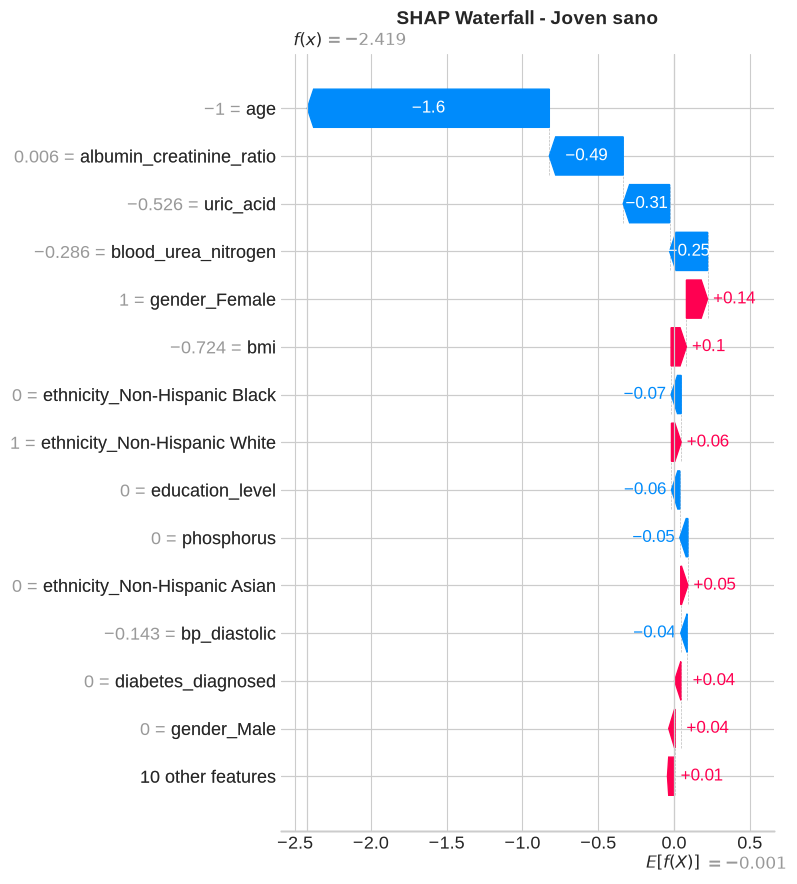

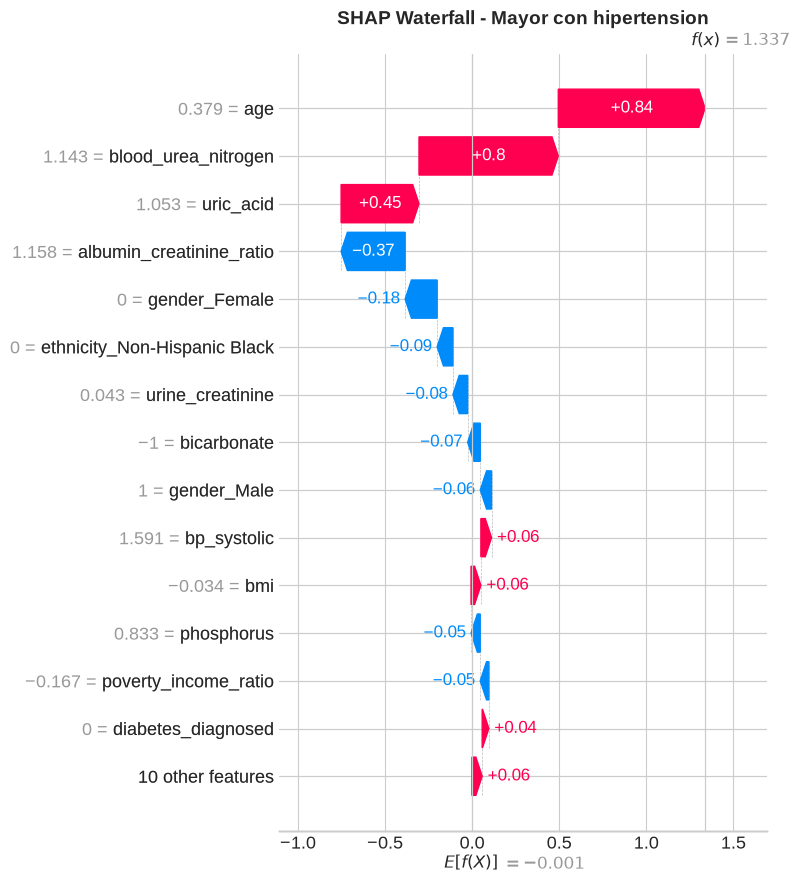

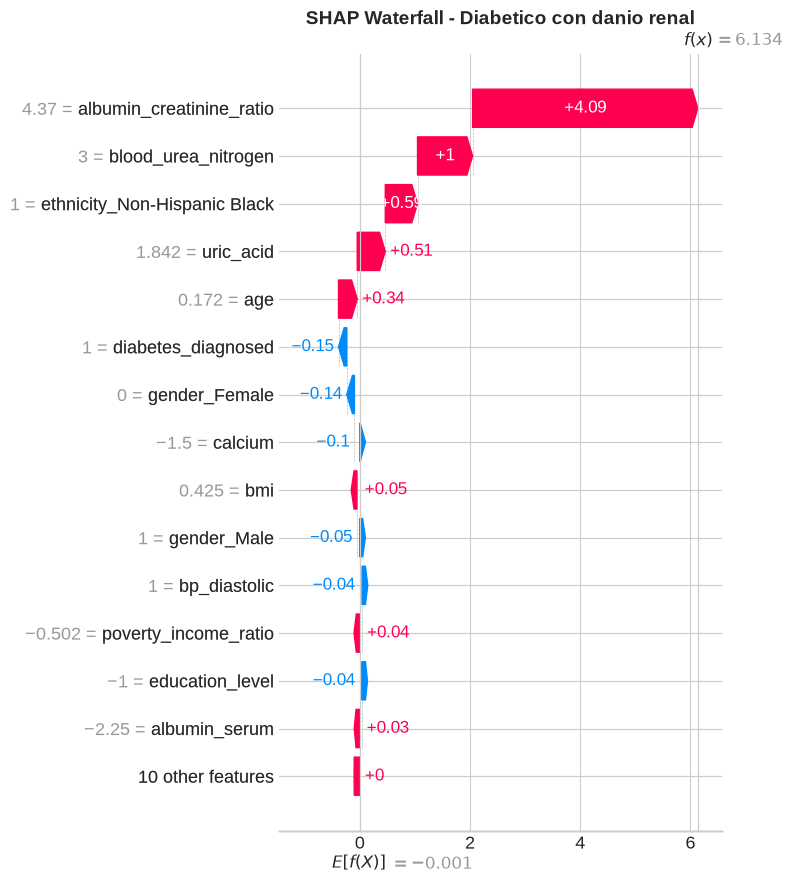

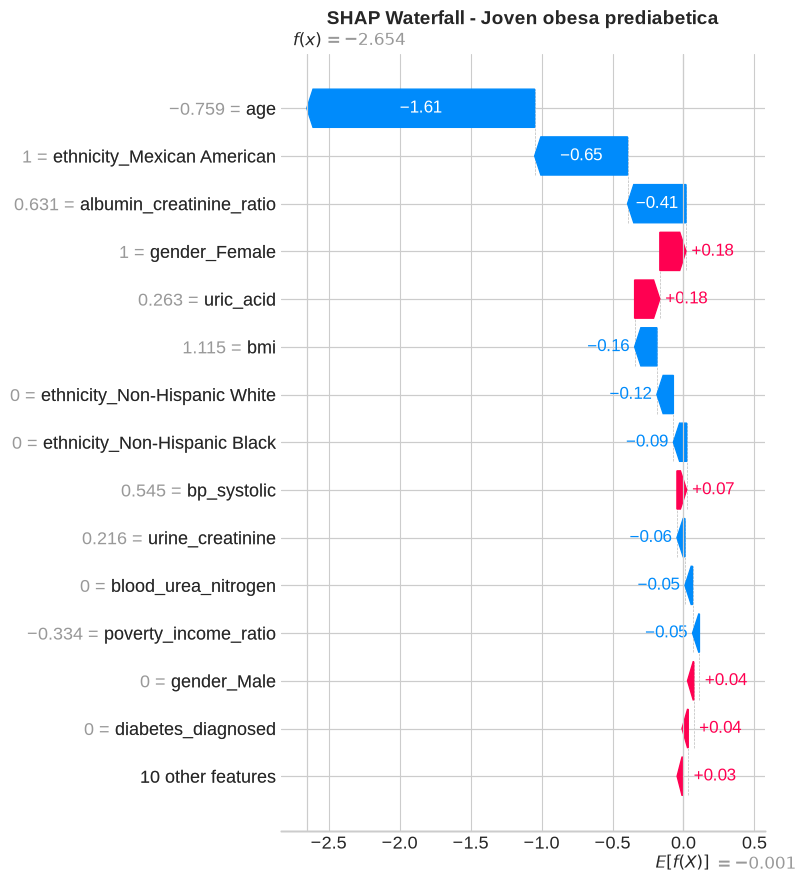

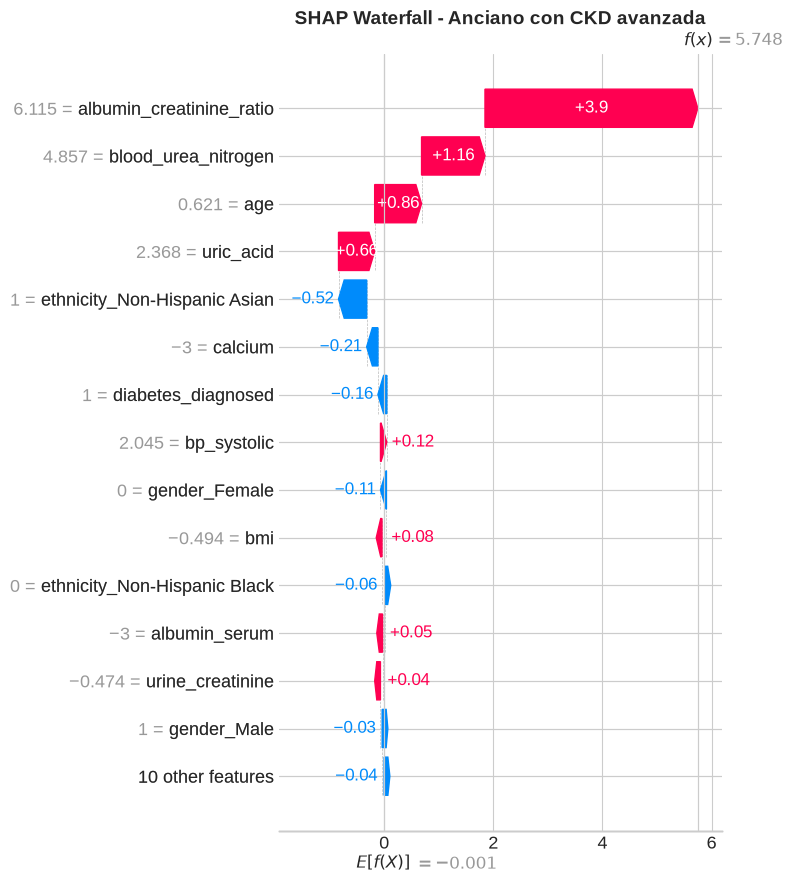


=== TABLA RESUMEN DE PACIENTES SIMULADOS ===
                 Paciente  Prob CKD Pred default Pred clinico                                                                                             Top 3 SHAP
               Joven sano    0.0817       No CKD       No CKD                                    age (-1.597), albumin_creatinine_ratio (-0.487), uric_acid (-0.306)
   Mayor con hipertension    0.7920          CKD          CKD                                         age (+0.843), blood_urea_nitrogen (+0.800), uric_acid (+0.447)
Diabetico con danio renal    0.9978          CKD          CKD albumin_creatinine_ratio (+4.087), blood_urea_nitrogen (+1.000), ethnicity_Non-Hispanic Black (+0.585)
 Joven obesa prediabetica    0.0657       No CKD       No CKD                   age (-1.605), ethnicity_Mexican American (-0.654), albumin_creatinine_ratio (-0.412)
 Anciano con CKD avanzada    0.9968          CKD          CKD                          albumin_creatinine_ratio (+3.901), blood_u

In [40]:
# =====================================================================
# APLICACION: PREDICCION SOBRE PACIENTES SIMULADOS
# =====================================================================
# 5 perfiles clinicos realistas (mismas 18 columnas de X_test, sin escalar).
# ACR ya esta en escala log1p (como quedo en df_labs).

pacientes = pd.DataFrame(
    [
        {
            "nombre": "Joven sano",
            "age": 28,
            "gender": "Female",
            "ethnicity": "Non-Hispanic White",
            "education_level": 4,
            "poverty_income_ratio": 3.5,
            "bmi": 22.0,
            "bp_systolic": 118,
            "bp_diastolic": 72,
            "blood_urea_nitrogen": 12,
            "albumin_serum": 4.2,
            "phosphorus": 3.5,
            "bicarbonate": 24,
            "calcium": 9.5,
            "uric_acid": 4.0,
            "urine_creatinine": 150,
            "albumin_creatinine_ratio": np.log1p(8),
            "diabetes_diagnosed": 0,
            "ever_smoked": 2,
        },
        {
            "nombre": "Mayor con hipertension",
            "age": 68,
            "gender": "Male",
            "ethnicity": "Non-Hispanic White",
            "education_level": 3,
            "poverty_income_ratio": 2.5,
            "bmi": 28.0,
            "bp_systolic": 155,
            "bp_diastolic": 92,
            "blood_urea_nitrogen": 22,
            "albumin_serum": 3.8,
            "phosphorus": 4.0,
            "bicarbonate": 22,
            "calcium": 9.2,
            "uric_acid": 7.0,
            "urine_creatinine": 120,
            "albumin_creatinine_ratio": np.log1p(25),
            "diabetes_diagnosed": 0,
            "ever_smoked": 1,
        },
        {
            "nombre": "Diabetico con danio renal",
            "age": 62,
            "gender": "Male",
            "ethnicity": "Non-Hispanic Black",
            "education_level": 2,
            "poverty_income_ratio": 1.5,
            "bmi": 32.0,
            "bp_systolic": 148,
            "bp_diastolic": 88,
            "blood_urea_nitrogen": 35,
            "albumin_serum": 3.2,
            "phosphorus": 4.8,
            "bicarbonate": 20,
            "calcium": 8.8,
            "uric_acid": 8.5,
            "urine_creatinine": 80,
            "albumin_creatinine_ratio": np.log1p(500),
            "diabetes_diagnosed": 1,
            "ever_smoked": 1,
        },
        {
            "nombre": "Joven obesa prediabetica",
            "age": 35,
            "gender": "Female",
            "ethnicity": "Mexican American",
            "education_level": 3,
            "poverty_income_ratio": 2.0,
            "bmi": 38.0,
            "bp_systolic": 132,
            "bp_diastolic": 82,
            "blood_urea_nitrogen": 14,
            "albumin_serum": 4.0,
            "phosphorus": 3.8,
            "bicarbonate": 23,
            "calcium": 9.4,
            "uric_acid": 5.5,
            "urine_creatinine": 140,
            "albumin_creatinine_ratio": np.log1p(15),
            "diabetes_diagnosed": 0,
            "ever_smoked": 2,
        },
        {
            "nombre": "Anciano con CKD avanzada",
            "age": 75,
            "gender": "Male",
            "ethnicity": "Non-Hispanic Asian",
            "education_level": 2,
            "poverty_income_ratio": 1.0,
            "bmi": 24.0,
            "bp_systolic": 165,
            "bp_diastolic": 78,
            "blood_urea_nitrogen": 48,
            "albumin_serum": 2.9,
            "phosphorus": 5.5,
            "bicarbonate": 18,
            "calcium": 8.2,
            "uric_acid": 9.5,
            "urine_creatinine": 60,
            "albumin_creatinine_ratio": np.log1p(2500),
            "diabetes_diagnosed": 1,
            "ever_smoked": 1,
        },
    ]
)

nombres = pacientes["nombre"].tolist()
# Ordenar igual que X_test (no usar la columna "nombre")
pacientes_X = pacientes[X_test.columns].copy()
print(f"Pacientes: {pacientes_X.shape} | Columnas: {list(pacientes_X.columns)}")

# 1) Preprocesar con el MISMO preprocesador ya ajustado
X_pac = preprocessor.transform(pacientes_X)

# 2) Probabilidades del mejor modelo
proba_pac = best_model.predict_proba(X_pac)[:, 1]

# 3) Aplicar los tres umbrales
umbrales_pac = {
    "Default (0.50)": 0.5,
    "Youden": thr_youden,
    "Clinico": thr_clin,
}
print("\n=== PROBABILIDAD DE CKD POR PACIENTE ===")
print(
    f"{'Paciente':<28}{'Prob CKD':>10}   "
    + "   ".join(f"{k.split('(')[0].strip():<8}" for k in umbrales_pac)
)
for nombre, prob in zip(nombres, proba_pac):
    preds = []
    for umbral in umbrales_pac.values():
        preds.append("CKD" if prob >= umbral else "No")
    print(f"{nombre:<28}{prob:>10.4f}   " + "   ".join(f"{p:<8}" for p in preds))

# 4) SHAP: waterfall por paciente
sv_pac = explainer.shap_values(X_pac)
if isinstance(sv_pac, list):
    sv_pac = sv_pac[1]
    base_pac = explainer.expected_value[1]
else:
    base_pac = explainer.expected_value

top3_por_paciente = []
for i, nombre in enumerate(nombres):
    top_idx = np.argsort(-np.abs(sv_pac[i]))[:3]
    top3 = [f"{all_features[j]} ({sv_pac[i][j]:+.3f})" for j in top_idx]
    top3_por_paciente.append(top3)

    expl_pac = shap.Explanation(
        values=sv_pac[i],
        base_values=base_pac,
        data=X_pac[i],
        feature_names=all_features,
    )
    plt.figure(figsize=(11, 7))
    shap.plots.waterfall(expl_pac, show=False, max_display=15)
    plt.title(f"SHAP Waterfall - {nombre}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

# 5) Tabla resumen
print("\n=== TABLA RESUMEN DE PACIENTES SIMULADOS ===")
resumen_pac = []
for i, nombre in enumerate(nombres):
    resumen_pac.append(
        {
            "Paciente": nombre,
            "Prob CKD": round(float(proba_pac[i]), 4),
            "Pred default": "CKD" if proba_pac[i] >= 0.5 else "No CKD",
            "Pred clinico": "CKD" if proba_pac[i] >= thr_clin else "No CKD",
            "Top 3 SHAP": ", ".join(top3_por_paciente[i]),
        }
    )
tabla_pac = pd.DataFrame(resumen_pac)
print(tabla_pac.to_string(index=False))

# 6) Parrafo interpretativo por paciente
interpretaciones = {
    "Joven sano": (
        "Sin factores de riesgo renal: ACR bajo (8), BUN y creatinina normales, PA "
        "normal, sin diabetes. El modelo deberia dar probabilidad BAJA y NO CKD con "
        "todos los umbrales. Tiene sentido clinico: una joven sana no debe ser "
        "referida a nefrologia."
    ),
    "Mayor con hipertension": (
        "Hipertension no controlada + edad avanzada + ACR de 25 (albuminuria leve, "
        "por debajo del criterio KDIGO de 30). Riesgo moderado: el modelo puede "
        "fluctuar entre umbrales. Este es el caso donde el umbral clinico (sens>=0.85) "
        "tiene valor: si marca CKD, se confirma con un examen, no se descarta."
    ),
    "Diabetico con danio renal": (
        "Triada de riesgo: diabetes, hipertension, ACR 500 (muy por encima de 30) y "
        "BUN elevado (35). Expectativa: CKD MUY PROBABLE con probabilidad alta y todos "
        "los umbrales concuerdan. Clinicamente coherente: este paciente ya tiene "
        "evidencia de danio renal."
    ),
    "Joven obesa prediabetica": (
        "Obesidad (BMI 38) y riesgo cardiometabolico, pero labs renales normales y ACR "
        "bajo (15). Expectativa: riesgo BAJO-MODERADO, probablemente No CKD o CKD solo "
        "con el umbral clinico. Coherente: sin albuminuria ni fallo de filtrado, no "
        "deberia tener CKD establecida."
    ),
    "Anciano con CKD avanzada": (
        "Cuadro de ERC terminal: ACR 2500, BUN 48, fosforo 5.5, bicarbonato 18 "
        "(acidosis), diabetes e hipertension. Expectativa: probabilidad ALTISIMA y CKD "
        "con los tres umbrales. El modelo debe detectar sin ambiguedad a un paciente "
        "que ya tiene enfermedad avanzada."
    ),
}

print("\n=== INTERPRETACION CLINICA ===")
for nombre in nombres:
    prob = float(proba_pac[nombres.index(nombre)])
    pred_d = "CKD" if prob >= 0.5 else "No CKD"
    pred_c = "CKD" if prob >= thr_clin else "No CKD"
    print(
        f"\n[{nombre}] Prob CKD = {prob:.4f} | default -> {pred_d} | clinico -> {pred_c}"
    )
    print(interpretaciones[nombre])

---
## APLICACION (comparativa): Pacientes simulados SIN ACR

Mismos 5 pacientes, pero quitando `albumin_creatinine_ratio`. Reutilizamos el
modelo de sensibilidad (`xgb_sens`, entrenado sin ACR en la seccion de analisis
de sensibilidad) y su preprocesador (`prep_sens`). Comparamos probabilidad y
waterfall SHAP CON vs SIN ACR para ver cuanto depende cada prediccion de la
albuminuria.


Pacientes sin ACR: 17 columnas
Features sin ACR: 23

=== PROBABILIDAD DE CKD: CON vs SIN ACR ===
                 Paciente  Prob CON ACR  Prob SIN ACR   Delta
               Joven sano        0.0817        0.1179  0.0362
   Mayor con hipertension        0.7920        0.8764  0.0844
Diabetico con danio renal        0.9978        0.9760 -0.0219
 Joven obesa prediabetica        0.0657        0.1438  0.0780
 Anciano con CKD avanzada        0.9968        0.9821 -0.0148

=== UMBRALES SIN ACR ===
Joven sano                      0.1179   No         No         No      
Mayor con hipertension          0.8764   CKD        CKD        CKD     
Diabetico con danio renal       0.9760   CKD        CKD        CKD     
Joven obesa prediabetica        0.1438   No         No         No      
Anciano con CKD avanzada        0.9821   CKD        CKD        CKD     


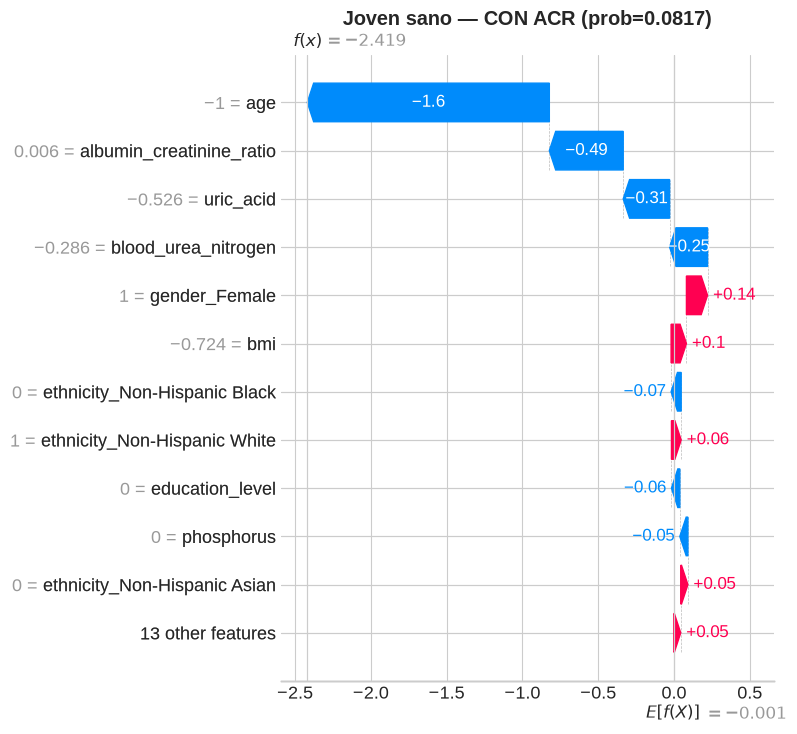

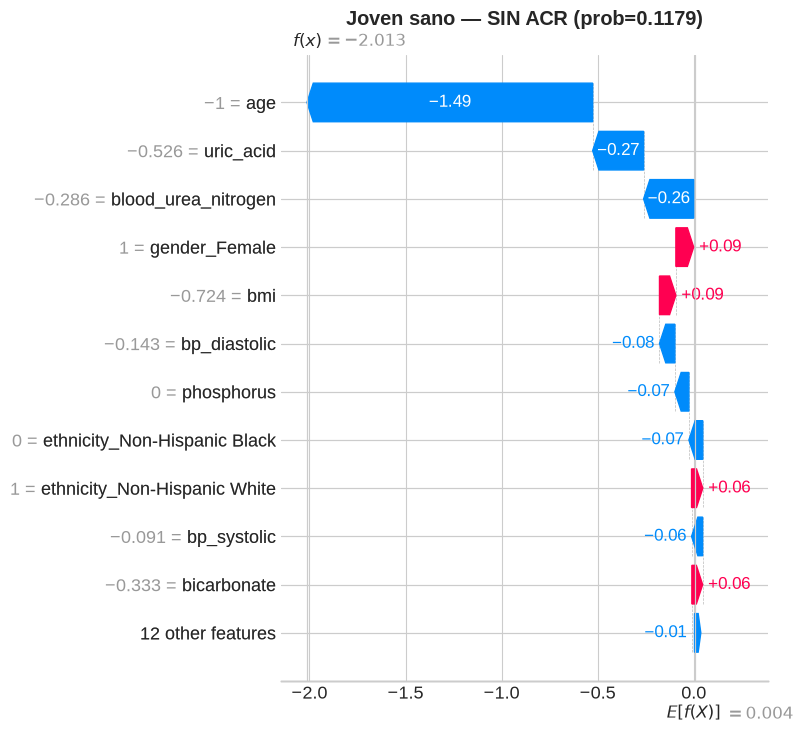

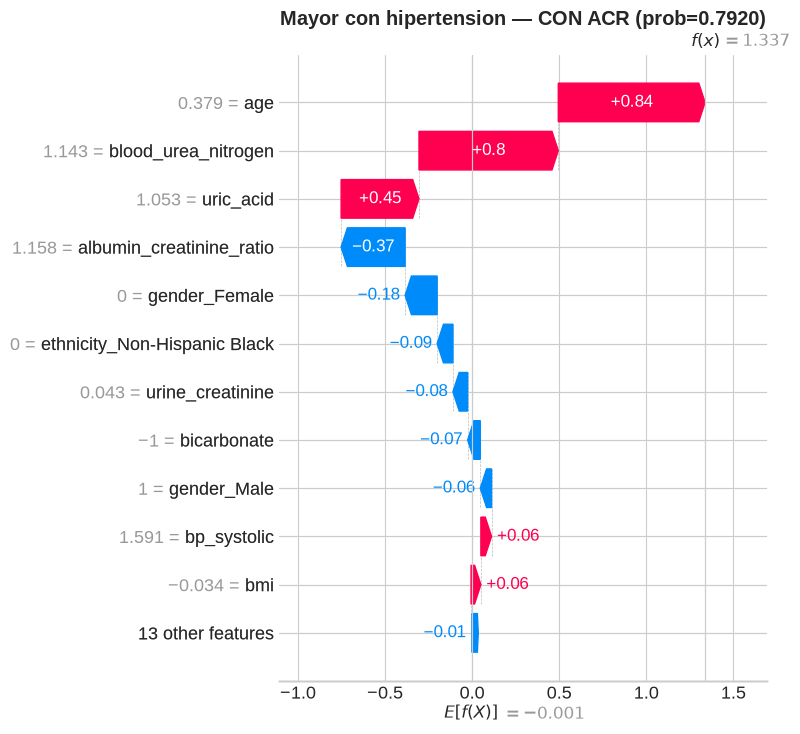

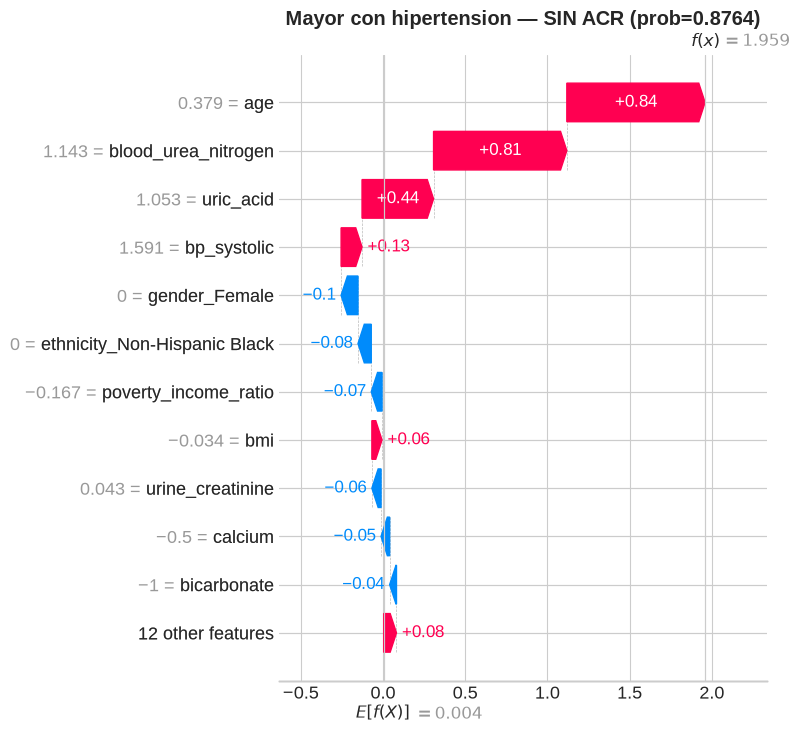

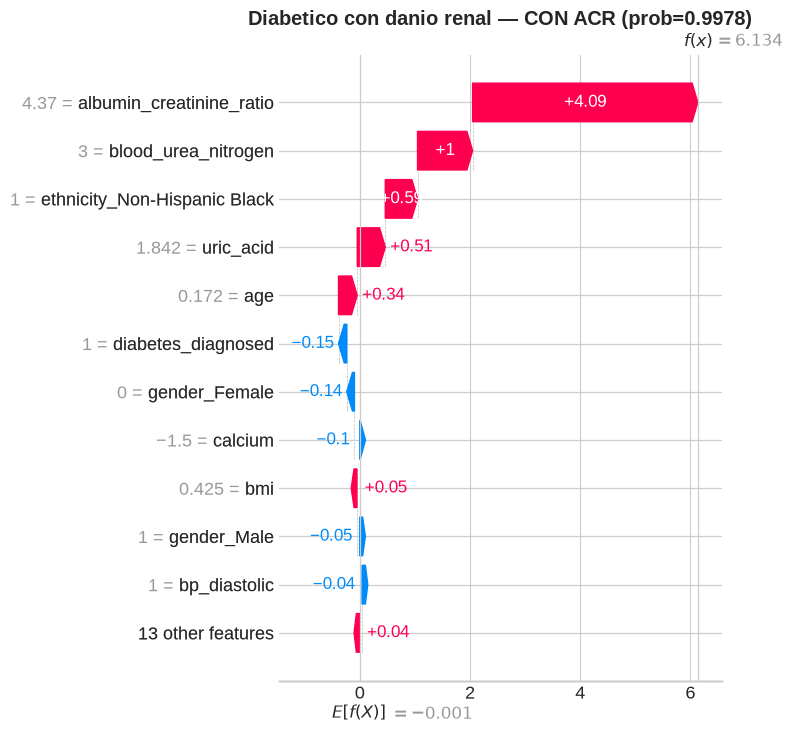

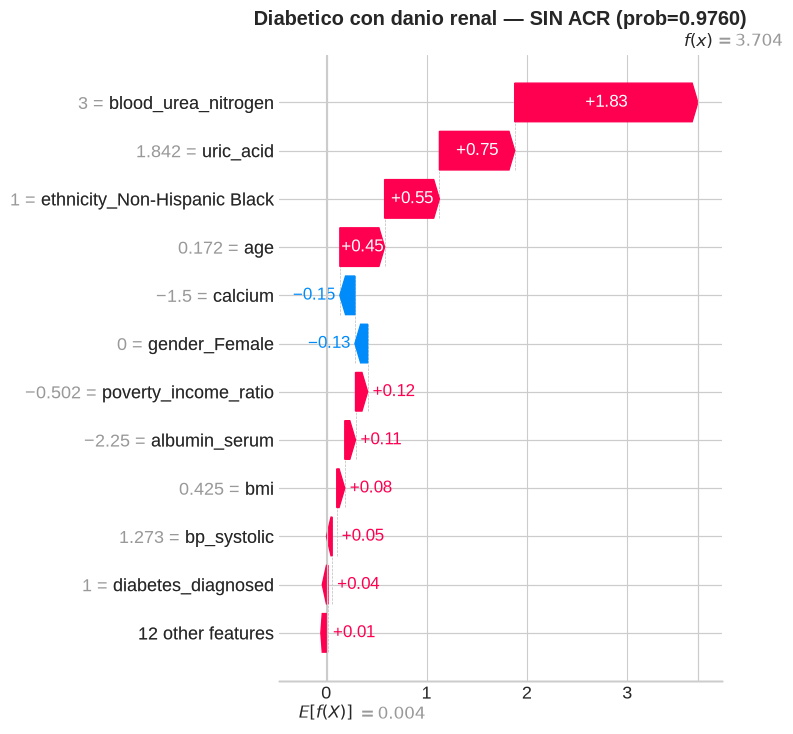

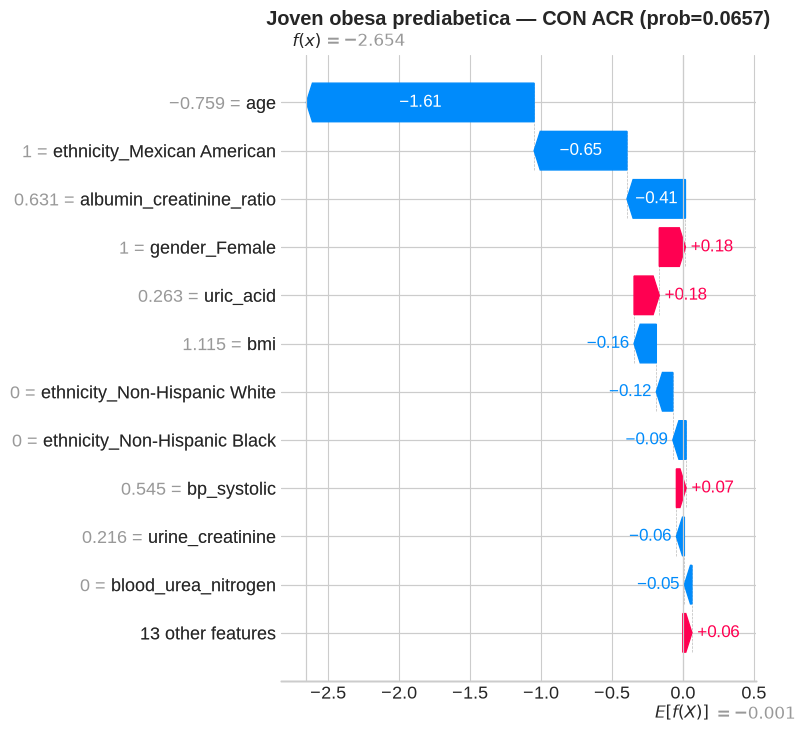

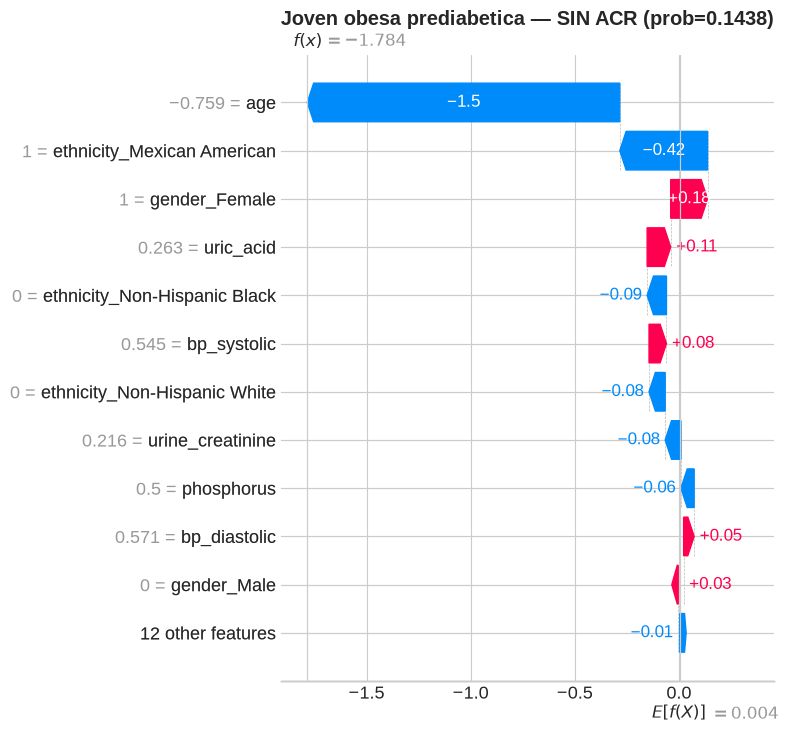

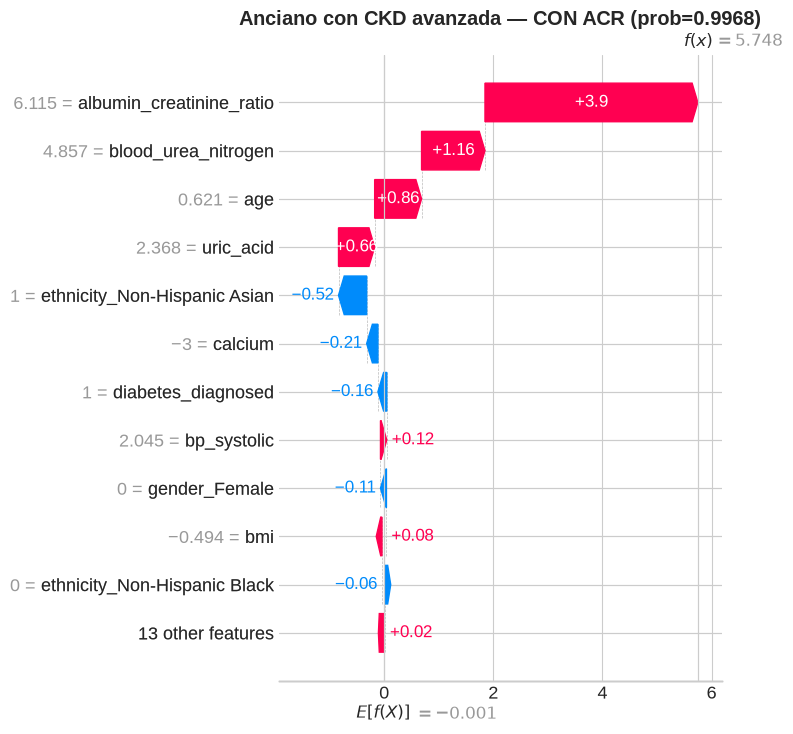

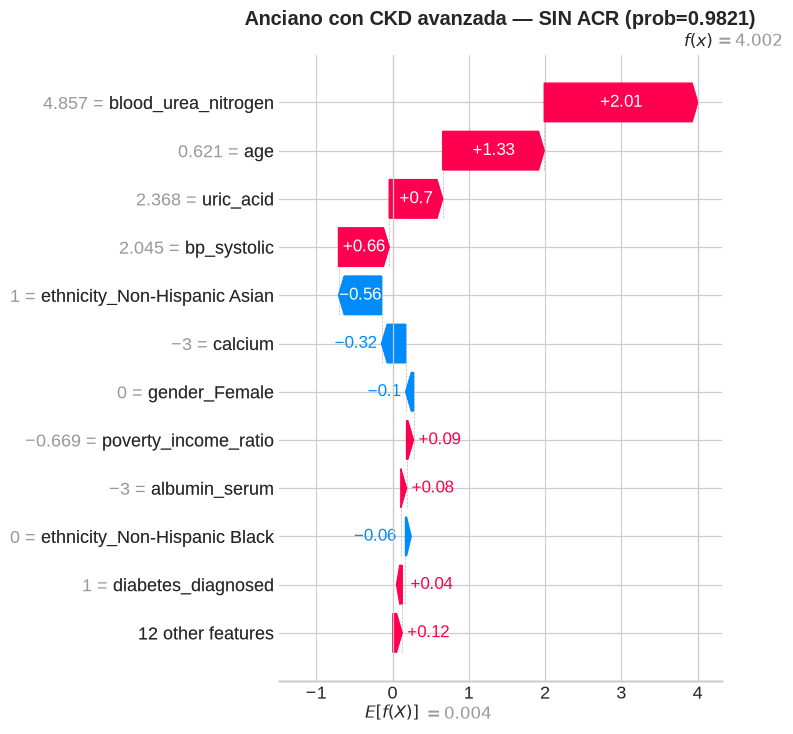


=== INTERPRETACION COMPARATIVA ===

[Joven sano] 0.0817 -> 0.1179 (+0.0362) | clinico: No CKD -> No CKD (se mantiene)
  El ACR apenas cambia la prediccion: el patron renal se sostiene con las demas variables (BUN, uric_acid, fosforo, bicarbonato).

[Mayor con hipertension] 0.7920 -> 0.8764 (+0.0844) | clinico: CKD -> CKD (se mantiene)
  Sin ACR la probabilidad SUBE: el modelo compensa con otras variables renales (el ACR estaba 'frenando' la prediccion).

[Diabetico con danio renal] 0.9978 -> 0.9760 (-0.0219) | clinico: CKD -> CKD (se mantiene)
  El ACR apenas cambia la prediccion: el patron renal se sostiene con las demas variables (BUN, uric_acid, fosforo, bicarbonato).

[Joven obesa prediabetica] 0.0657 -> 0.1438 (+0.0780) | clinico: No CKD -> No CKD (se mantiene)
  Sin ACR la probabilidad SUBE: el modelo compensa con otras variables renales (el ACR estaba 'frenando' la prediccion).

[Anciano con CKD avanzada] 0.9968 -> 0.9821 (-0.0148) | clinico: CKD -> CKD (se mantiene)
  El ACR a

In [42]:
# =====================================================================
# APLICACION COMPARATIVA: MISMOS PACIENTES SIN ACR
# =====================================================================
# Quitar ACR del DataFrame de pacientes (mismas filas, mismo orden)
pacientes_no_acr = pacientes_X.drop(columns=["albumin_creatinine_ratio"])
print(f"Pacientes sin ACR: {pacientes_no_acr.shape[1]} columnas")

# Preprocesar con el preprocesador de sensibilidad (ya ajustado sin ACR)
X_pac_no_acr = prep_sens.transform(pacientes_no_acr)

# Probabilidad del modelo sin ACR (xgb_sens de la seccion de sensibilidad)
proba_no_acr = xgb_sens.predict_proba(X_pac_no_acr)[:, 1]

# Feature names del preprocesador de sensibilidad
cat_names_sens = prep_sens.named_transformers_["cat"]["encoder"].get_feature_names_out(
    categorical_s
)
all_features_sens = list(numeric_s) + list(cat_names_sens)
print(f"Features sin ACR: {len(all_features_sens)}")

# Tabla comparativa: probabilidad CON vs SIN ACR
print("\n=== PROBABILIDAD DE CKD: CON vs SIN ACR ===")
comp = pd.DataFrame(
    {
        "Paciente": nombres,
        "Prob CON ACR": np.round(proba_pac, 4),
        "Prob SIN ACR": np.round(proba_no_acr, 4),
        "Delta": np.round(proba_no_acr - proba_pac, 4),
    }
)
print(comp.to_string(index=False))

# Predicciones con los 3 umbrales (sin ACR)
print("\n=== UMBRALES SIN ACR ===")
for nombre, prob in zip(nombres, proba_no_acr):
    preds = []
    for umbral in umbrales_pac.values():
        preds.append("CKD" if prob >= umbral else "No")
    print(f"{nombre:<28}{prob:>10.4f}   " + "   ".join(f"{p:<8}" for p in preds))

# SHAP del modelo SIN ACR
explainer_sens = shap.TreeExplainer(xgb_sens)
sv_sens = explainer_sens.shap_values(X_pac_no_acr)
if isinstance(sv_sens, list):
    sv_sens = sv_sens[1]
    base_sens = explainer_sens.expected_value[1]
else:
    base_sens = explainer_sens.expected_value

# Waterfall CON vs SIN ACR para cada paciente
for i, nombre in enumerate(nombres):
    expl_con = shap.Explanation(
        values=sv_pac[i],
        base_values=base_pac,
        data=X_pac[i],
        feature_names=all_features,
    )
    plt.figure(figsize=(11, 7))
    shap.plots.waterfall(expl_con, show=False, max_display=12)
    plt.title(f"{nombre} — CON ACR (prob={proba_pac[i]:.4f})", fontweight="bold")
    plt.tight_layout()
    plt.show()

    expl_sin = shap.Explanation(
        values=sv_sens[i],
        base_values=base_sens,
        data=X_pac_no_acr[i],
        feature_names=all_features_sens,
    )
    plt.figure(figsize=(11, 7))
    shap.plots.waterfall(expl_sin, show=False, max_display=12)
    plt.title(f"{nombre} — SIN ACR (prob={proba_no_acr[i]:.4f})", fontweight="bold")
    plt.tight_layout()
    plt.show()

# Interpretacion: en que pacientes el ACR cambia la decision
print("\n=== INTERPRETACION COMPARATIVA ===")
for i, nombre in enumerate(nombres):
    prob_con = float(proba_pac[i])
    prob_sin = float(proba_no_acr[i])
    pred_con = "CKD" if prob_con >= thr_clin else "No CKD"
    pred_sin = "CKD" if prob_sin >= thr_clin else "No CKD"
    cambio = "CAMBIA" if pred_con != pred_sin else "se mantiene"
    print(
        f"\n[{nombre}] {prob_con:.4f} -> {prob_sin:.4f} ({prob_sin - prob_con:+.4f}) | "
        f"clinico: {pred_con} -> {pred_sin} ({cambio})"
    )
    if prob_con - prob_sin > 0.05:
        print(
            "  El ACR aporta informacion importante: sin el, la probabilidad baja"
            " sustancialmente y el modelo depende de BUN, uric_acid y fosforo."
        )
    elif prob_sin - prob_con > 0.05:
        print(
            "  Sin ACR la probabilidad SUBE: el modelo compensa con otras"
            " variables renales (el ACR estaba 'frenando' la prediccion)."
        )
    else:
        print(
            "  El ACR apenas cambia la prediccion: el patron renal se sostiene"
            " con las demas variables (BUN, uric_acid, fosforo, bicarbonato)."
        )

---
## FASE 10: Resumen

In [41]:
print("=" * 60)
print("RESUMEN FINAL")
print("=" * 60)
print(
    f"\nDataset: {df.shape[0]} registros -> {df_labs.shape[0]} con labs -> {len(all_features)} features"
)
print("Eliminadas por fuga: egfr, ckd_stage, serum_creatinine")
print(
    "Eliminadas no predictoras: participant_id, weight_kg, height_cm,\n      insulin_use, diabetes_pills, current_smoker"
)
print("Eliminadas por redundancia: urine_albumin (redundante con ACR)")
print("Preprocesamiento: KNNImputer + RobustScaler + log1p(ACR)")
print("Balanceo: SMOTE")
print("Optimizacion: GridSearchCV")
print(f"\nMejor modelo: {best_name}")
print(f"AUC-ROC (test): {roc_auc_score(y_test, y_prob):.4f}")
print(f"AUC-PR (test):  {average_precision_score(y_test, y_prob):.4f}")
print("\nTop 5 variables (SHAP):")
for _, row in shap_importance.head(5).iterrows():
    print(f"  - {row['Feature']}: {row['Mean |SHAP|']:.4f}")

RESUMEN FINAL

Dataset: 11933 registros -> 5444 con labs -> 24 features
Eliminadas por fuga: egfr, ckd_stage, serum_creatinine
Eliminadas no predictoras: participant_id, weight_kg, height_cm,
      insulin_use, diabetes_pills, current_smoker
Eliminadas por redundancia: urine_albumin (redundante con ACR)
Preprocesamiento: KNNImputer + RobustScaler + log1p(ACR)
Balanceo: SMOTE
Optimizacion: GridSearchCV

Mejor modelo: XGBoost (optimizado)
AUC-ROC (test): 0.8791
AUC-PR (test):  0.8867

Top 5 variables (SHAP):
  - age: 1.0429
  - albumin_creatinine_ratio: 0.7986
  - blood_urea_nitrogen: 0.4394
  - uric_acid: 0.2959
  - urine_creatinine: 0.1525


### Limitaciones
- NHANES es transversal (no captura cronicidad de 3 meses KDIGO)
- ACR podria tener fuga parcial si definio ckd_present
- Poblacion estadounidense (requiere validacion externa)
- Se excluyeron eGFR y serum_creatinine para evitar circularidad

### Trabajo futuro
- Clasificacion multiclase (G1-G5)
- Sistema jerarquico binario + multiclase
- Validacion con cohortes externas
- Incorporar hemoglobina, cistatina C, HbA1c
- Modelos de progresion temporal
- Despliegue como herramienta clinica